Testing out pynaple and dandi env on this dataset: https://dandiarchive.org/dandiset/001695/0.260319.2023

In [1]:
import sys
# install into THIS kernel's interpreter (pynapple_dandi_env), not system python
!{sys.executable} -m pip install hmmlearn

In [2]:
import sys
# sys.executable = the exact python running THIS kernel (your pynapple_dandi_env)
# using "-m pip" guarantees the matching pip, not whatever `pip` resolves to on PATH
!{sys.executable} -m pip install matplotlib
print("\nInstalled into:", sys.executable)


Installed into: /storage/conda_envs/pynapple_dandi_env/bin/python


In [3]:
from pathlib import Path
from dandi.dandiapi import DandiAPIClient
import pynapple as nap

# ---- config ----
DANDISET_ID = "001695"
VERSION_ID  = "0.260319.2023"
SUBJECT     = "sub-M01/"                                  # which subject to scan
DOWNLOAD_DIR = Path("../../storage/dandi_downloads").resolve()
DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)          # storage folder (create if missing)

# ---- discover sessions, pick smallest to keep it quick ----
with DandiAPIClient() as client:
    dandiset = client.get_dandiset(DANDISET_ID, VERSION_ID)
    sessions = [(a.path, a.size)
                for a in dandiset.get_assets_with_path_prefix(SUBJECT, order="path")]
    # behavior+ecephys sessions are the ones with position data; prefer those
    behavior = [s for s in sessions if "behavior" in s[0]]
    pool = behavior or sessions                          # fall back to any if none flagged
    target_path = min(pool, key=lambda t: t[1])[0]       # smallest in the pool
    print("Picked:", target_path)

    # ---- download into storage (make nested sub-XX/ parent first) ----
    asset = dandiset.get_asset_by_path(target_path)
    asset_out = DOWNLOAD_DIR / target_path
    asset_out.parent.mkdir(parents=True, exist_ok=True)  # download() won't create dirs
    if not asset_out.exists():                           # skip re-download if already local
        asset.download(asset_out)
    print("Local file:", asset_out)

# ---- load in pynapple ----
data = nap.load_file(str(asset_out))
print("\nObjects in this NWB file:")
print(data)                                              # look here for position/behavior keys

# ---- find spatial-navigation data ----
# pynapple exposes NWB objects by key; spatial data is usually a TsdFrame of x/y
# common keys across datasets: "position", "SpatialSeries", "head_position", etc.
spatial_keys = [k for k in data.keys()
                if any(w in k.lower() for w in ["position", "spatial", "pos", "head"])]
print("\nCandidate spatial keys:", spatial_keys)

if spatial_keys:
    pos = data[spatial_keys[0]]                          # TsdFrame: columns are x/y (/z)
    print(f"\nUsing '{spatial_keys[0]}':")
    print(pos)
    print("Columns:", list(getattr(pos, "columns", [])))
    print("Time span (s):", pos.index[-1] - pos.index[0])
else:
    print("\nNo obvious spatial key — print(data) above to see actual object names.")

Picked: sub-M01/sub-M01_ses-20240313T100000_behavior+ecephys.nwb
Local file: /storage/dandi_downloads/sub-M01/sub-M01_ses-20240313T100000_behavior+ecephys.nwb


/storage/conda_envs/pynapple_dandi_env/lib/python3.11/site-packages/numcodecs/__init__.py:106: DeprecationWarning: crc32c usage is deprecated since numcodecs v0.16.4. It is recommended to install google_crc32c instead.
  from numcodecs.checksum32 import CRC32, Adler32, JenkinsLookup3



Objects in this NWB file:
sub-M01_ses-20240313T100000_behavior+ecephys
┍━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┯━━━━━━━━━━━━━┑
│ Keys                        │ Type        │
┝━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┿━━━━━━━━━━━━━┥
│ units                       │ TsGroup     │
│ SleepStates                 │ IntervalSet │
│ Best_Ripple_channel_LFP_CA1 │ TsdFrame    │
│ Speed                       │ Tsd         │
│ Position                    │ TsdFrame    │
┕━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┷━━━━━━━━━━━━━┙

Candidate spatial keys: ['Position']

Using 'Position':
Time (s)                  x        y
------------------  -------  -------
4892.8469000000005  10.2028  15.5703
4892.8872854166675  10.204   15.5773
4892.927670833334   10.204   15.5891
4892.968056250001   10.204   15.6471
4893.008441666667   10.2028  15.6471
4893.048827083334   10.1692  15.6471
4893.0892125        10.1194  15.6471
...
6520.931772357723   43.0673  16.3426
6520.972332520325   43.477   16.3957
6521.012892682927   44.0497  16.4489
6521.0534

In [4]:
import pynapple as nap
from pathlib import Path

asset_out = Path("../../storage/dandi_downloads/sub-M01/"
                 "sub-M01_ses-20240313T100000_behavior+ecephys.nwb").resolve()
data = nap.load_file(str(asset_out))

# ---- pynapple's view: top-level objects and their types ----
print("=" * 60)
print("PYNAPPLE OBJECTS")
print("=" * 60)
print(data)

# ---- units TsGroup: metadata columns + shape ----
units = data["units"]
print("\n" + "=" * 60)
print("UNITS (TsGroup)")
print("=" * 60)
print("n_units:", len(units))
print("metadata_columns:", list(units.metadata_columns))
print("\nfull metadata table:")
print(units.metadata)                     # every per-unit column, all rows

# ---- each non-units object: type, shape, columns, time span ----
print("\n" + "=" * 60)
print("OTHER OBJECTS")
print("=" * 60)
for key in data.keys():
    if key == "units":
        continue
    obj = data[key]
    line = f"{key:32s} {type(obj).__name__}"
    if hasattr(obj, "columns"):
        line += f"  cols={list(obj.columns)}"
    if hasattr(obj, "shape"):
        line += f"  shape={obj.shape}"
    if hasattr(obj, "index") and len(obj) > 0:
        line += f"  t=[{obj.index[0]:.1f}, {obj.index[-1]:.1f}]s"
    elif hasattr(obj, "start"):            # IntervalSet
        line += f"  n_intervals={len(obj)}"
    print(line)

# ---- raw NWB hierarchy (the underlying file, everything pynapple didn't surface) ----
print("\n" + "=" * 60)
print("RAW NWB TREE")
print("=" * 60)
try:
    import pynwb, h5py
    with pynwb.NWBHDF5IO(str(asset_out), mode="r") as io:
        nwb = io.read()
        print(nwb)                          # full NWB object: acquisition, processing, intervals, etc.
except Exception as e:
    print("Could not open raw NWB:", e)

PYNAPPLE OBJECTS
sub-M01_ses-20240313T100000_behavior+ecephys
┍━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┯━━━━━━━━━━━━━┑
│ Keys                        │ Type        │
┝━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┿━━━━━━━━━━━━━┥
│ units                       │ TsGroup     │
│ SleepStates                 │ IntervalSet │
│ Best_Ripple_channel_LFP_CA1 │ TsdFrame    │
│ Speed                       │ Tsd         │
│ Position                    │ TsdFrame    │
┕━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┷━━━━━━━━━━━━━┙

UNITS (TsGroup)
n_units: 240
metadata_columns: ['rate', 'cell_type', 'cell_area', 'firing_rate', 'ab_ratio', 'burstIndex_Mizuseki2012', 'cv2', 'maxWaveformCh', 'troughToPeak', 'acg_tau_decay', 'acg_tau_rise', 'thetaModulationIndex', 'x_position_probe', 'y_position_probe']

full metadata table:
         rate           cell_type cell_area  firing_rate  ab_ratio  \
1    9.909396  Narrow Interneuron       CA3     9.909626 -0.535097   
2    7.957887  Narrow Interneuron       CA3     7.959234 -0.172564   
3    0.815371     

/storage/conda_envs/pynapple_dandi_env/lib/python3.11/site-packages/pynapple/io/interface_nwb.py:133: UserWarning: end is not sorted. Cannot add metadata to unsorted end times. Sorting it and dropping metadata.
  data = nap.IntervalSet(df)
/storage/conda_envs/pynapple_dandi_env/lib/python3.11/site-packages/pynapple/io/interface_nwb.py:133: UserWarning: Some starts precede the previous end. Joining them!
  data = nap.IntervalSet(df)
/storage/conda_envs/pynapple_dandi_env/lib/python3.11/site-packages/pynapple/io/interface_nwb.py:133: UserWarning: epochs have changed, dropping metadata.
  data = nap.IntervalSet(df)


Best_Ripple_channel_LFP_CA1      TsdFrame  cols=[0]  shape=(13985972, 1)  t=[0.0, 11188.8]s
Speed                            Tsd  shape=(40708,)  t=[4892.8, 6521.2]s
Position                         TsdFrame  cols=['x', 'y']  shape=(40708, 2)  t=[4892.8, 6521.2]s

RAW NWB TREE
root pynwb.file.NWBFile at 0x139657201965776
Fields:
  devices: {
    Neuropixels 2.0 <class 'pynwb.device.Device'>
  }
  electrode_groups: {
    ElectrodeGroup1 <class 'pynwb.ecephys.ElectrodeGroup'>
  }
  electrodes: electrodes <class 'pynwb.ecephys.ElectrodesTable'>
  experimenter: ['Mihály Vöröslakos']
  file_create_date: [datetime.datetime(2026, 1, 13, 16, 16, 18, 804970, tzinfo=tzoffset(None, -18000))]
  identifier: name
  institution: NYU
  intervals: {
    SleepStates <class 'pynwb.epoch.TimeIntervals'>
  }
  lab: Buzsáki Lab
  processing: {
    behavior <class 'pynwb.base.ProcessingModule'>,
    ecephys <class 'pynwb.base.ProcessingModule'>
  }
  session_description: Novel Maze Session with Pre and Post 

Metadata columns on units: ['rate', 'cell_type', 'cell_area', 'firing_rate', 'ab_ratio', 'burstIndex_Mizuseki2012', 'cv2', 'maxWaveformCh', 'troughToPeak', 'acg_tau_decay', 'acg_tau_rise', 'thetaModulationIndex', 'x_position_probe', 'y_position_probe']

Counts (region x cell_type, with Total):
type  Total  Narrow Interneuron  Pyramidal Cell  Wide Interneuron
area                                                             
CA1     103                  15              85                 3
CA3      83                  55              27                 1
RSC      54                  23              15                16


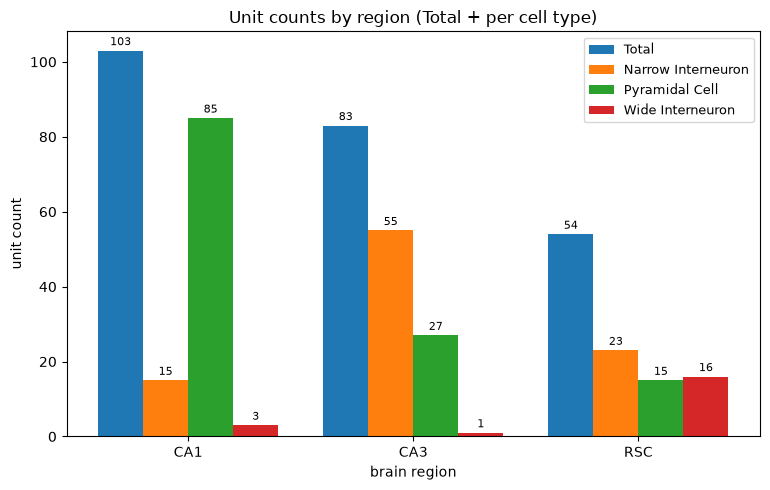

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# per-unit metadata available on the TsGroup (summary scores + labels, not spikes)
print("Metadata columns on units:", list(units.metadata_columns))

region_col = "cell_area"   # region label; 'cell_type' = narrow/wide interneuron etc.

regions = np.asarray(units.get_info(region_col))
cell_types = np.asarray(units.get_info("cell_type"))

# build a region x cell_type count table, then add a "Total" column
tab = pd.crosstab(pd.Series(regions, name="area"),
                  pd.Series(cell_types, name="type"))
tab.insert(0, "Total", tab.sum(axis=1))   # Total first, then each cell type
print("\nCounts (region x cell_type, with Total):")
print(tab)

# ---- grouped bar plot: regions on X, (Total + each cell_type) bars per region ----
areas = tab.index.tolist()          # X groups
cols = tab.columns.tolist()         # bars within each group: ['Total', type1, type2, ...]
n_bars = len(cols)
x = np.arange(len(areas))
width = 0.8 / n_bars                 # fit all bars within each region slot

fig, ax = plt.subplots(figsize=(1.6 * len(areas) + 3, 5))
cmap = plt.get_cmap("tab10")

for i, col in enumerate(cols):
    offsets = x + (i - (n_bars - 1) / 2) * width   # center the group on the tick
    bars = ax.bar(offsets, tab[col].values, width,
                  label=col, color=cmap(i))
    ax.bar_label(bars, padding=2, fontsize=8)      # count above each bar

ax.set_xticks(x); ax.set_xticklabels(areas)
ax.set(xlabel="brain region", ylabel="unit count",
       title="Unit counts by region (Total + per cell type)")
ax.legend(title="", fontsize=9)
plt.tight_layout(); plt.show()

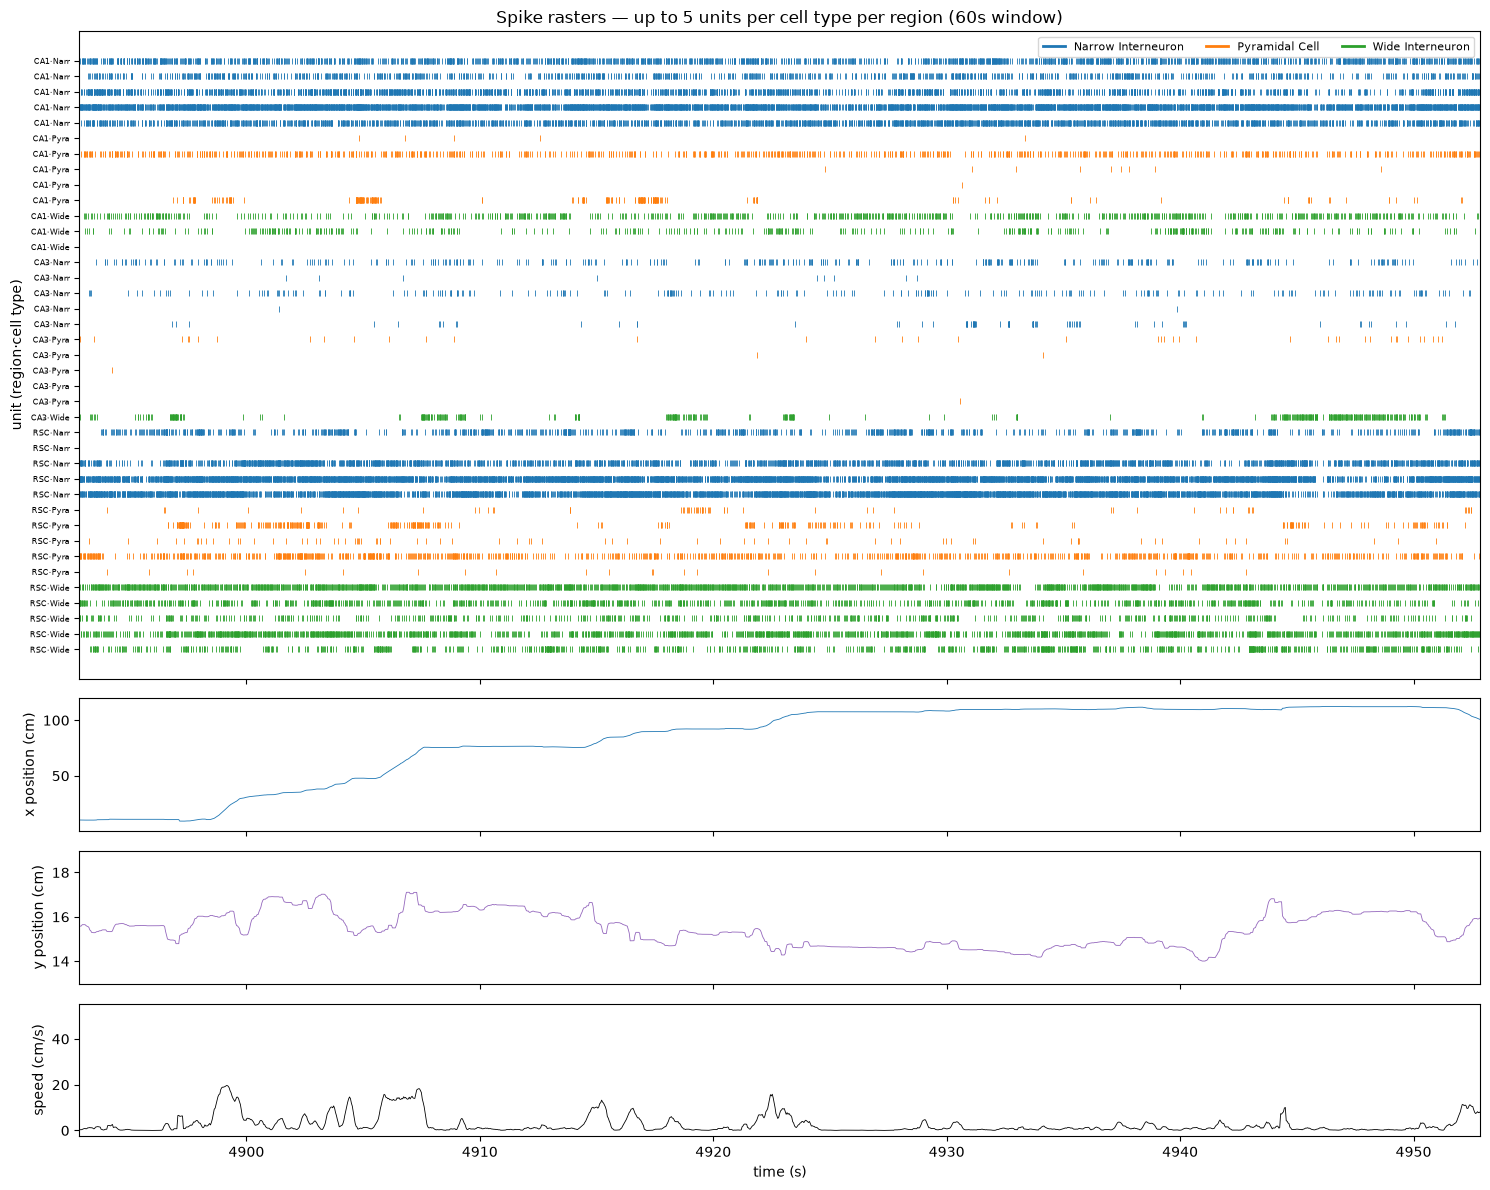

Showing 39 units | window 4893–4953 s


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path
import pynapple as nap

# ---- reload objects from the file so the cell stands alone ----
session_nwb_path = Path("../../storage/dandi_downloads/sub-M01/"
                        "sub-M01_ses-20240313T100000_behavior+ecephys.nwb").resolve()
session_nwb  = nap.load_file(str(session_nwb_path))
spike_group  = session_nwb["units"]        # TsGroup: 240 units, spike times + per-unit metadata
position_xy  = session_nwb["Position"]      # TsdFrame x/y, maze epoch only

n_units_per_group = 5     # neurons to show per (region, cell_type) combo
raster_window_s   = 60    # seconds to display in the raster (short window so spikes are legible)

# ---- compute running speed from position (not reliably provided in the file) ----
position_time_s = position_xy.index.values
position_x_vals = position_xy["x"].values
position_y_vals = position_xy["y"].values
# instantaneous speed = distance between consecutive samples / dt  (units: position-units / s)
dt_s = np.diff(position_time_s)
dxy = np.sqrt(np.diff(position_x_vals)**2 + np.diff(position_y_vals)**2)
speed_vals = dxy / dt_s
speed_time_s = position_time_s[1:]               # speed is defined between samples
# light smoothing over ~0.25 s to reduce sample-to-sample jitter
smooth_n = max(1, int(0.25 / np.median(dt_s)))
speed_vals_smooth = np.convolve(speed_vals, np.ones(smooth_n)/smooth_n, mode="same")

# ---- per-unit metadata arrays ----
unit_brain_regions = np.asarray(spike_group.get_info("cell_area"))   # CA1 / CA3 / RSC
unit_cell_types    = np.asarray(spike_group.get_info("cell_type"))   # Narrow/Wide Interneuron, Pyramidal Cell
unit_id_keys       = np.asarray(spike_group.index)                   # 1-based unit keys

cell_type_names  = sorted(set(unit_cell_types))
cell_type_colors = {ct: c for ct, c in zip(cell_type_names, plt.get_cmap("tab10").colors)}

# ---- pick up to n neurons per region x cell_type ----
selected_units = []   # (unit_id, brain_region, cell_type)
for brain_region in sorted(set(unit_brain_regions)):
    for cell_type in cell_type_names:
        matching_unit_ids = unit_id_keys[(unit_brain_regions == brain_region)
                                         & (unit_cell_types == cell_type)]
        for unit_id in matching_unit_ids[:n_units_per_group]:
            selected_units.append((unit_id, brain_region, cell_type))

# ---- display window: first raster_window_s of the maze epoch ----
window_start_s = position_time_s[0]
window_end_s   = window_start_s + raster_window_s

fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=True,
                         gridspec_kw={"height_ratios": [len(selected_units)/8, 1, 1, 1]})

# ---- panel 0: spike raster (windowed) ----
raster_ax = axes[0]
for raster_row, (unit_id, brain_region, cell_type) in enumerate(selected_units):
    unit_spike_times = spike_group[unit_id].get(window_start_s, window_end_s)
    raster_ax.plot(unit_spike_times.index.values,
                   np.full(len(unit_spike_times), raster_row), "|",
                   color=cell_type_colors[cell_type], markersize=4, mew=0.6)
raster_ax.set_yticks(range(len(selected_units)))
raster_ax.set_yticklabels([f"{r[:4]}·{c[:4]}" for _, r, c in selected_units], fontsize=6)
raster_ax.set(ylabel="unit (region·cell type)",
              title=f"Spike rasters — up to 5 units per cell type per region "
                    f"({raster_window_s}s window)")
raster_ax.invert_yaxis()
raster_ax.legend(handles=[Line2D([0],[0], color=cell_type_colors[ct], lw=2, label=ct)
                          for ct in cell_type_names],
                 fontsize=8, loc="upper right", ncol=len(cell_type_names))

# ---- panels 1 & 2: position x and y ----
axes[1].plot(position_time_s, position_x_vals, lw=0.6, color="tab:blue")
axes[1].set(ylabel="x position (cm)")
axes[2].plot(position_time_s, position_y_vals, lw=0.6, color="tab:purple")
axes[2].set(ylabel="y position (cm)")

# ---- panel 3: computed running speed ----
axes[3].plot(speed_time_s, speed_vals_smooth, lw=0.6, color="k")
axes[3].set(ylabel="speed (cm/s)", xlabel="time (s)")

axes[0].set_xlim(window_start_s, window_end_s)   # all panels locked to the window
plt.tight_layout(); plt.show()

print(f"Showing {len(selected_units)} units | window {window_start_s:.0f}–{window_end_s:.0f} s")

Overall recording bounds
units    : 0.00 to 11188.78 s  (11188.77 s)
position : 4892.85 to 6521.18 s  (1628.33 s)
speed    : 4892.85 to 6521.18 s  (1628.33 s)

Sleep intervals
01: 1.00 to 2140.00 s  (2139.00 s)
02: 2141.00 to 2220.00 s  (79.00 s)
03: 2229.00 to 2261.00 s  (32.00 s)
04: 2266.00 to 2317.00 s  (51.00 s)
05: 2323.00 to 2394.00 s  (71.00 s)
06: 2400.00 to 2454.00 s  (54.00 s)
07: 2460.00 to 2768.00 s  (308.00 s)
08: 2769.00 to 2808.00 s  (39.00 s)
09: 2809.00 to 2981.00 s  (172.00 s)
10: 2987.00 to 3094.00 s  (107.00 s)
11: 3102.00 to 3140.00 s  (38.00 s)
12: 3149.00 to 3267.00 s  (118.00 s)
13: 3268.00 to 3349.00 s  (81.00 s)
14: 3350.00 to 3391.00 s  (41.00 s)
15: 3392.00 to 3399.00 s  (7.00 s)
16: 3400.00 to 3437.00 s  (37.00 s)
17: 3437.99 to 3575.00 s  (137.01 s)
18: 3583.00 to 3616.00 s  (33.00 s)
19: 3621.00 to 3737.00 s  (116.00 s)
20: 3745.00 to 3761.00 s  (16.00 s)
21: 3767.99 to 3869.00 s  (101.01 s)
22: 3875.00 to 3893.00 s  (18.00 s)
23: 3899.00 to 3975.00 s  (

/storage/conda_envs/pynapple_dandi_env/lib/python3.11/site-packages/pynapple/io/interface_nwb.py:133: UserWarning: end is not sorted. Cannot add metadata to unsorted end times. Sorting it and dropping metadata.
  data = nap.IntervalSet(df)
/storage/conda_envs/pynapple_dandi_env/lib/python3.11/site-packages/pynapple/io/interface_nwb.py:133: UserWarning: Some starts precede the previous end. Joining them!
  data = nap.IntervalSet(df)
/storage/conda_envs/pynapple_dandi_env/lib/python3.11/site-packages/pynapple/io/interface_nwb.py:133: UserWarning: epochs have changed, dropping metadata.
  data = nap.IntervalSet(df)


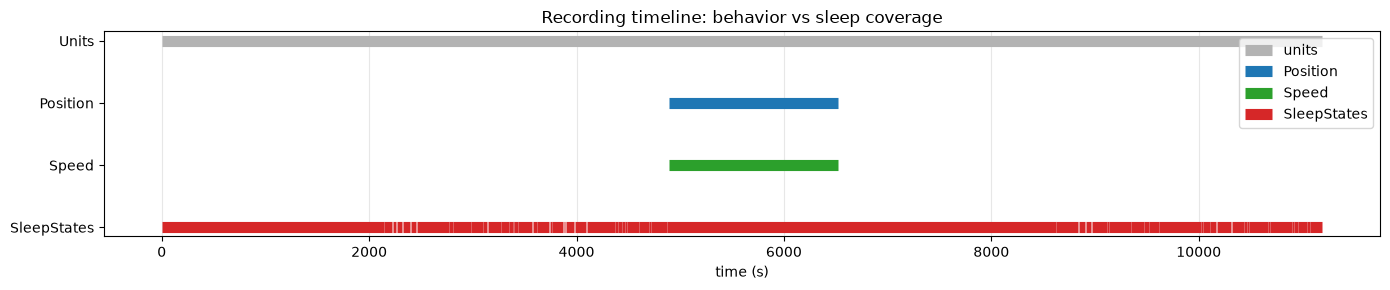

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# reuse objects already loaded above
sleep_intervals = session_nwb["SleepStates"]
speed_tsd = session_nwb["Speed"]
position_tsd = session_nwb["Position"]
units_tsgroup = session_nwb["units"]

# ---- helper to get overall spike-data bounds ----
all_starts = []
all_ends = []
for unit_id in units_tsgroup.index:
    spike_times = units_tsgroup[unit_id].index.values
    if len(spike_times):
        all_starts.append(spike_times[0])
        all_ends.append(spike_times[-1])

units_start = min(all_starts)
units_end = max(all_ends)

position_start = position_tsd.index[0]
position_end = position_tsd.index[-1]

speed_start = speed_tsd.index[0]
speed_end = speed_tsd.index[-1]

print("Overall recording bounds")
print(f"units    : {units_start:.2f} to {units_end:.2f} s  ({units_end - units_start:.2f} s)")
print(f"position : {position_start:.2f} to {position_end:.2f} s  ({position_end - position_start:.2f} s)")
print(f"speed    : {speed_start:.2f} to {speed_end:.2f} s  ({speed_end - speed_start:.2f} s)")

print("\nSleep intervals")
sleep_starts = np.asarray(sleep_intervals.start)
sleep_ends = np.asarray(sleep_intervals.end)
for i, (s, e) in enumerate(zip(sleep_starts, sleep_ends), start=1):
    print(f"{i:02d}: {s:.2f} to {e:.2f} s  ({e - s:.2f} s)")

# ---- quick overlap summary ----
print("\nBehavior epoch likely covered by Position/Speed")
print(f"behavior : {max(position_start, speed_start):.2f} to {min(position_end, speed_end):.2f} s")

# ---- timeline plot ----
fig, ax = plt.subplots(figsize=(14, 3))

# full spike recording
ax.plot([units_start, units_end], [3, 3], lw=8, color="0.7", solid_capstyle="butt", label="units")

# position/speed coverage
ax.plot([position_start, position_end], [2, 2], lw=8, color="tab:blue", solid_capstyle="butt", label="Position")
ax.plot([speed_start, speed_end], [1, 1], lw=8, color="tab:green", solid_capstyle="butt", label="Speed")

# sleep intervals
for j, (s, e) in enumerate(zip(sleep_starts, sleep_ends)):
    ax.plot([s, e], [0, 0], lw=8, color="tab:red", solid_capstyle="butt",
            label="SleepStates" if j == 0 else None)

ax.set_yticks([0, 1, 2, 3])
ax.set_yticklabels(["SleepStates", "Speed", "Position", "Units"])
ax.set_xlabel("time (s)")
ax.set_title("Recording timeline: behavior vs sleep coverage")
ax.legend(loc="upper right")
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

                     metric         value
0                 n_samples  40708.000000
1                duration_s   1628.328233
2                mean_speed      5.988872
3                 std_speed     10.390624
4              median_speed      1.278501
5                 p95_speed     32.233967
6                 p99_speed     44.174036
7                 max_speed     52.128170
8   speed_cap_mean_plus_3sd     37.160743
9            frac_above_cap      0.031001
10                 raw_skew      2.248731
11                 log_skew      0.286038


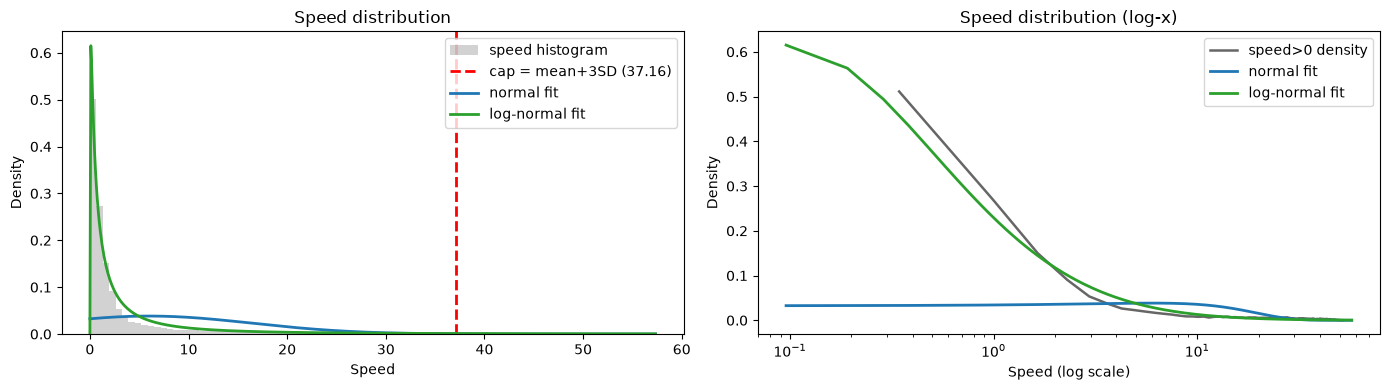

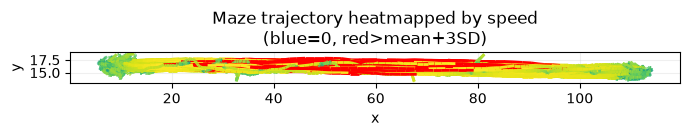

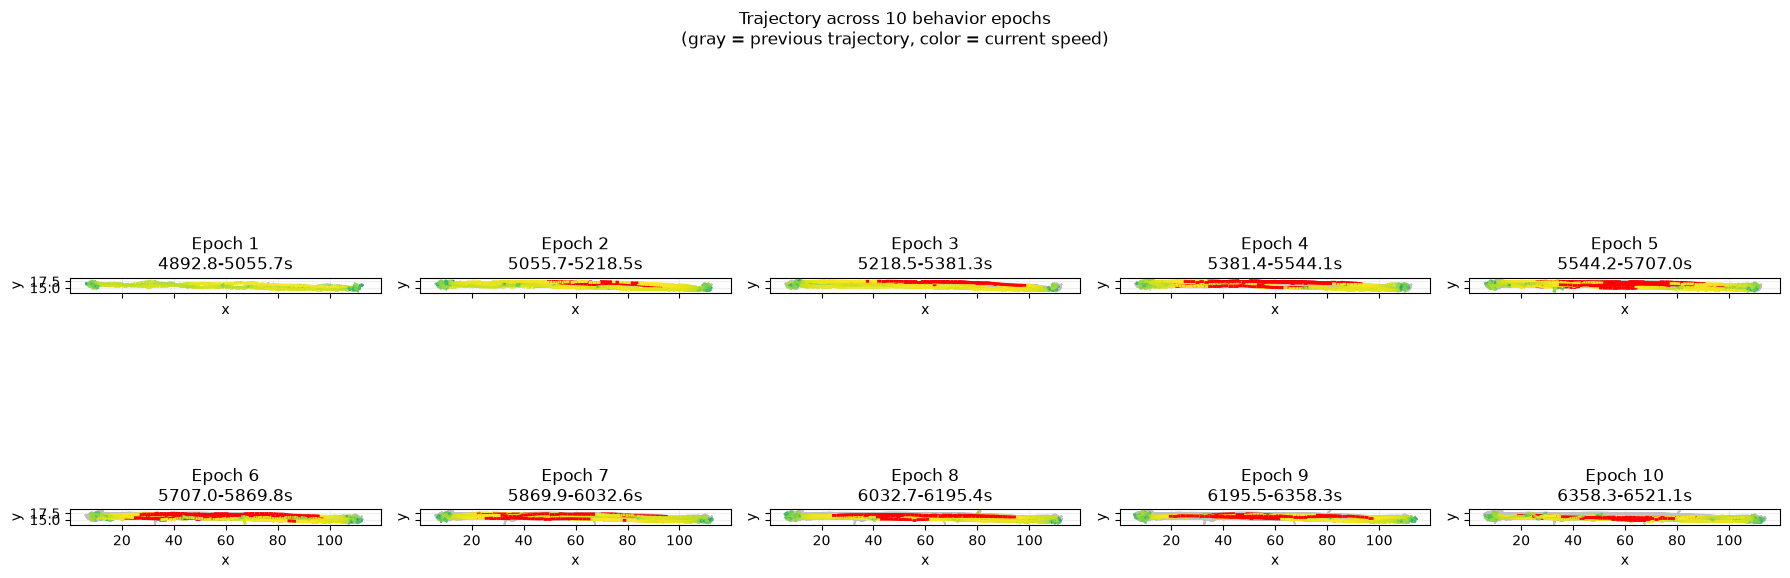

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import LogNorm
import copy

# ---------- Inputs ----------
pos = session_nwb["Position"]
has_speed = "Speed" in session_nwb.keys()
spd_obj = session_nwb["Speed"] if has_speed else None

# ---------- Build behavior dataframe ----------
t = np.asarray(pos.index.values, dtype=float)
x = np.asarray(pos["x"].values, dtype=float)
y = np.asarray(pos["y"].values, dtype=float)

good = np.isfinite(t) & np.isfinite(x) & np.isfinite(y)
t, x, y = t[good], x[good], y[good]

dt = np.diff(t, prepend=t[0])
dx = np.diff(x, prepend=x[0])
dy = np.diff(y, prepend=y[0])

speed_pos = np.zeros_like(t)
mask = dt > 0
speed_pos[mask] = np.sqrt(dx[mask]**2 + dy[mask]**2) / dt[mask]

if has_speed:
    ts = np.asarray(spd_obj.index.values, dtype=float)
    vs = np.asarray(spd_obj.values, dtype=float)
    ok = np.isfinite(ts) & np.isfinite(vs)
    ts, vs = ts[ok], vs[ok]
    speed = np.interp(t, ts, vs) if len(ts) > 1 else speed_pos
else:
    speed = speed_pos

speed = np.clip(speed, 0, None)

df = pd.DataFrame({"t": t, "x": x, "y": y, "speed": speed}).dropna().reset_index(drop=True)

# ---------- Speed cap: mean + 3 SD ----------
mu = df["speed"].mean()
sd = df["speed"].std(ddof=1)
cap = mu + 3 * sd
df["speed_clip"] = np.minimum(df["speed"], cap)
df["is_over_cap"] = df["speed"] > cap

# ---------- Diagnostic stats ----------
def skewness(v):
    v = np.asarray(v, dtype=float)
    v = v[np.isfinite(v)]
    if len(v) < 3:
        return np.nan
    m = v.mean()
    s = v.std(ddof=0)
    if s == 0:
        return 0.0
    return np.mean(((v - m) / s) ** 3)

eps = 1e-6
raw_skew = skewness(df["speed"].values)
log_skew = skewness(np.log(df["speed"].values + eps))

stats = pd.DataFrame({
    "metric": [
        "n_samples", "duration_s", "mean_speed", "std_speed", "median_speed",
        "p95_speed", "p99_speed", "max_speed", "speed_cap_mean_plus_3sd",
        "frac_above_cap", "raw_skew", "log_skew"
    ],
    "value": [
        len(df),
        df["t"].iloc[-1] - df["t"].iloc[0],
        df["speed"].mean(),
        df["speed"].std(ddof=1),
        df["speed"].median(),
        df["speed"].quantile(0.95),
        df["speed"].quantile(0.99),
        df["speed"].max(),
        cap,
        df["is_over_cap"].mean(),
        raw_skew,
        log_skew
    ]
})
print(stats)

# ---------- Plot 1: speed distribution ----------
v = df["speed"].values
vpos = v[v > 0]
if len(vpos) == 0:
    raise ValueError("No positive speed samples available.")

fig, ax = plt.subplots(1, 2, figsize=(14, 4))

# Left: full histogram + fits
ax[0].hist(v, bins=80, density=True, alpha=0.35, color="gray", label="speed histogram")
ax[0].axvline(cap, color="red", ls="--", lw=2, label=f"cap = mean+3SD ({cap:.2f})")

m, s = np.mean(v), np.std(v, ddof=0) + 1e-12
grid = np.linspace(0, max(v.max(), cap) * 1.1, 600)
normal_pdf = (1 / (s * np.sqrt(2*np.pi))) * np.exp(-0.5 * ((grid - m) / s) ** 2)

lv = np.log(vpos + eps)
ml, sl = lv.mean(), lv.std(ddof=0) + 1e-12
logn_pdf = (1 / ((grid + eps) * sl * np.sqrt(2*np.pi))) * np.exp(-0.5 * ((np.log(grid + eps) - ml) / sl) ** 2)

ax[0].plot(grid, normal_pdf, color="tab:blue", lw=2, label="normal fit")
ax[0].plot(grid, logn_pdf, color="tab:green", lw=2, label="log-normal fit")
ax[0].set_title("Speed distribution")
ax[0].set_xlabel("Speed")
ax[0].set_ylabel("Density")
ax[0].legend()

# Right: log-x, no shaded histogram
counts, bins = np.histogram(vpos, bins=80, density=True)
centers = 0.5 * (bins[:-1] + bins[1:])
ax[1].plot(centers, counts, color="0.4", lw=1.8, label="speed>0 density")
ax[1].plot(grid[grid > 0], normal_pdf[grid > 0], color="tab:blue", lw=2, label="normal fit")
ax[1].plot(grid[grid > 0], logn_pdf[grid > 0], color="tab:green", lw=2, label="log-normal fit")
ax[1].set_xscale("log")
ax[1].set_title("Speed distribution (log-x)")
ax[1].set_xlabel("Speed (log scale)")
ax[1].set_ylabel("Density")
ax[1].legend()

plt.tight_layout()
plt.show()

# ---------- Colormap + helper (fixed error, no cm.get_cmap) ----------
base_cmap = plt.get_cmap("viridis")
cmap = base_cmap.copy() if hasattr(base_cmap, "copy") else copy.copy(base_cmap)
cmap.set_under("blue")   # speed == 0
cmap.set_over("red")     # speed > cap
norm = LogNorm(vmin=1e-3, vmax=cap)

def colored_line_log(ax, xseg, yseg, speedseg, cmap_obj, norm_obj):
    pts = np.array([xseg, yseg]).T.reshape(-1, 1, 2)
    segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
    c = np.asarray(speedseg[:-1], dtype=float)
    c = np.where(np.isfinite(c), c, 0.0)
    c = np.where(c > cap, cap * 1.0001, c)  # force over-range to "red"
    lc = LineCollection(segs, cmap=cmap_obj, norm=norm_obj)
    lc.set_array(c)
    lc.set_linewidth(2.0)
    ax.add_collection(lc)
    return lc

# ---------- Plot 2: full trajectory (no colorbar) ----------
fig, ax = plt.subplots(figsize=(7, 7))
_ = colored_line_log(ax, df["x"].values, df["y"].values, df["speed"].values, cmap, norm)
ax.set_aspect("equal", adjustable="box")
ax.set_title("Maze trajectory heatmapped by speed\n(blue=0, red>mean+3SD)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# ---------- Plot 3: 10 temporal epochs with gray history (no colorbar) ----------
n_epochs = 10
idx_edges = np.linspace(0, len(df)-1, n_epochs+1).astype(int)

fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharex=True, sharey=True)
axes = axes.ravel()

for k in range(n_epochs):
    ax = axes[k]
    i0, i1 = idx_edges[k], idx_edges[k+1]
    if i1 <= i0 + 2:
        ax.set_title(f"Epoch {k+1}: too short")
        continue

    if i0 > 1:
        ax.plot(df["x"].values[:i0], df["y"].values[:i0], color="0.7", lw=1.2, alpha=0.8)

    xk = df["x"].values[i0:i1]
    yk = df["y"].values[i0:i1]
    sk = df["speed"].values[i0:i1]
    _ = colored_line_log(ax, xk, yk, sk, cmap, norm)

    t0, t1 = df["t"].values[i0], df["t"].values[i1-1]
    ax.set_title(f"Epoch {k+1}\n{t0:.1f}-{t1:.1f}s")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(alpha=0.2)

fig.suptitle("Trajectory across 10 behavior epochs\n(gray = previous trajectory, color = current speed)", y=1.02)
for a in axes:
    a.set_xlabel("x")
    a.set_ylabel("y")
plt.tight_layout()
plt.show()


Maze epoch: 4892.85 to 6521.18 s (1628.33 s)
Units before/after restrict: 240 / 240
Building MAZE-only spike matrix (50 ms bins, per-neuron z-score)...
  done in 0.3s | matrix = (32567, 240) (time_bins, units)

[K=10] fitting...


         1 -10529062.73571103             +nan
         2 -1083293.08154583 +9445769.65416520
         3 7227586.95048278 +8310880.03202861
         4 8282735.15274638 +1055148.20226359
         5 8630303.39515313 +347568.24240675
         6 8824173.01672367 +193869.62157054
         7 8859689.74383572  +35516.72711205
         8 8889408.27002955  +29718.52619383
         9 8904646.73547839  +15238.46544884
        10 8923109.00456817  +18462.26908978
        11 9000962.62838785  +77853.62381969
        12 9007312.90882259   +6350.28043474
        13 9013107.90987090   +5795.00104831
        14 9016965.50051410   +3857.59064320
        15 9022223.17397914   +5257.67346504
        16 9027262.26901019   +5039.09503106
        17 9028637.76933721   +1375.50032702
        18 9028710.20552794     +72.43619073
        19 9028770.91779702     +60.71226908
        20 9028777.25607338      +6.33827636
        21 9028792.81374093     +15.55766755
        22 9028797.33757218      +4.52383125
    

[K=10] done in  21.5s | iters= 23 | converged=True | loglik=9,028,797

[K=9] fitting...


         1 -10625643.26886231             +nan
         2 -847528.52242899 +9778114.74643333
         3 7296753.46826614 +8144281.99069513
         4 8315299.37679660 +1018545.90853046
         5 8609742.53436925 +294443.15757265
         6 8725509.88154975 +115767.34718050
         7 8877223.84225474 +151713.96070499
         8 9004205.63499337 +126981.79273863
         9 9113473.45259086 +109267.81759750
        10 9131074.44107090  +17600.98848004
        11 9135066.15177030   +3991.71069941
        12 9136083.13617246   +1016.98440216
        13 9136501.03259380    +417.89642134
        14 9137323.70826301    +822.67566921
        15 9149366.12383262  +12042.41556961
        16 9153449.03059272   +4082.90676010
        17 9153506.59317503     +57.56258230
        18 9153529.46572508     +22.87255006
        19 9153529.29673072      -0.16899437
Model is not converging.  Current: 9153529.29673072 is not greater than 9153529.465725085. Delta is -0.168994365260005


[K=9] done in  16.2s | iters= 19 | converged=True | loglik=9,153,529

[K=8] fitting...


...

[K=3] done in   4.2s | iters= 12 | converged=True | loglik=1,370,419

[K=2] fitting...


         1 -10665573.28427999             +nan
         2 -8844725.94546139 +1820847.33881859
         3 -5030553.67966530 +3814172.26579610
         4 -4157141.67519989 +873412.00446541
         5 -3177720.63251511 +979421.04268478
         6 -2222767.56465449 +954953.06786062
         7 -1737713.85104731 +485053.71360718
         8 -1688168.04109632  +49545.80995099
         9 -1673971.44470120  +14196.59639512
        10 -1656556.17183328  +17415.27286792
        11 -1492435.01389082 +164121.15794247
        12 -1492427.41364115      +7.60024967
        13 -1492424.35783047      +3.05581068
        14 -1492424.19551280      +0.16231767


[K=2] done in   4.5s | iters= 15 | converged=True | loglik=-1,492,424



        15 -1492424.19143446      +0.00407834


Sweep finished in 120.5s total

                loglik           AIC           BIC  n_params
n_states                                                    
2        -1.492424e+06  2.986774e+06  2.994855e+06       963
3         1.370419e+06 -2.737942e+06 -2.725792e+06      1448
4         3.117874e+06 -6.231878e+06 -6.215641e+06      1935
5         7.183228e+06 -1.436161e+07 -1.434127e+07      2424
6         6.970061e+06 -1.393429e+07 -1.390983e+07      2915
7         6.931825e+06 -1.385683e+07 -1.382824e+07      3408
8         9.366976e+06 -1.872615e+07 -1.869340e+07      3903
9         9.153529e+06 -1.829826e+07 -1.826134e+07      4400
10        9.028797e+06 -1.804780e+07 -1.800669e+07      4899


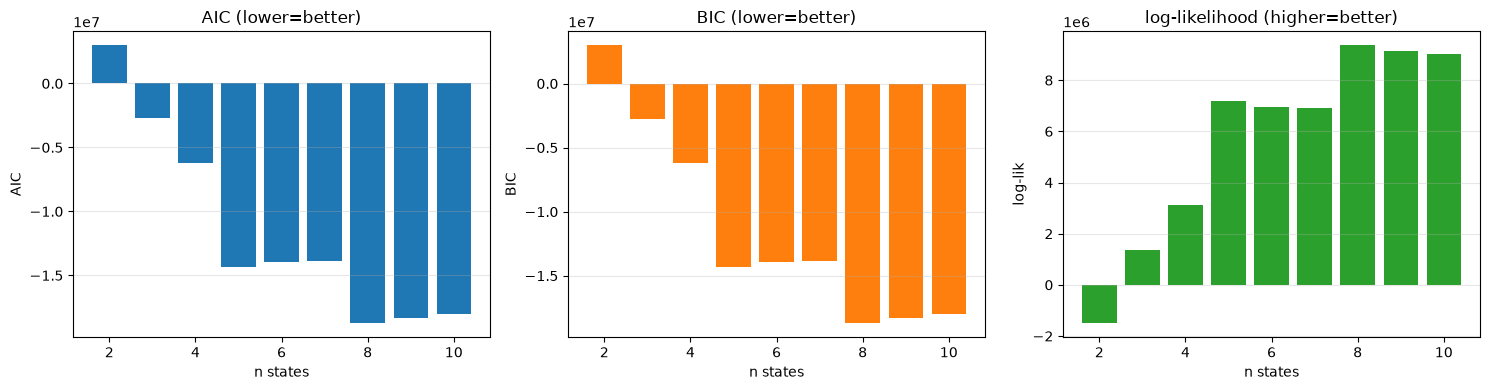

BIC picks K=8


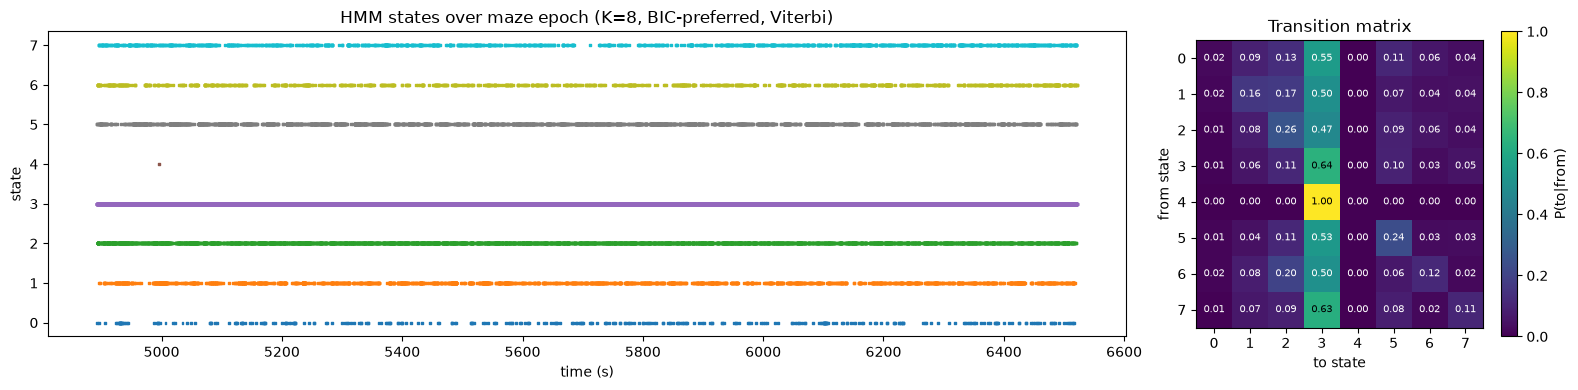

Stored models: [2, 3, 4, 5, 6, 7, 8, 9, 10]


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from hmmlearn.hmm import GaussianHMM
import pynapple as nap  # needed for IntervalSet

# ============================================================
# reusable spike-matrix builder
# ============================================================
def build_spike_matrix(spike_group, bin_size_s=0.050, zscore=True, smooth_sigma_bins=None):
    binned = spike_group.count(bin_size_s)
    bin_times_s = binned.index.values
    matrix = binned.values.astype(float)

    if smooth_sigma_bins:
        from scipy.ndimage import gaussian_filter1d
        matrix = gaussian_filter1d(matrix, smooth_sigma_bins, axis=0)

    if zscore:
        unit_mean = matrix.mean(axis=0)
        unit_std = matrix.std(axis=0)
        unit_std[unit_std == 0] = 1
        matrix = (matrix - unit_mean) / unit_std
    return matrix, bin_times_s

# ============================================================
# RESTRICT TO MAZE EPOCH (from Position timestamps)
# ============================================================
maze_start = float(position_xy.index[0])     # or session_nwb["Position"].index[0]
maze_end   = float(position_xy.index[-1])    # or session_nwb["Position"].index[-1]
maze_ep = nap.IntervalSet(start=maze_start, end=maze_end)

spike_group_maze = spike_group.restrict(maze_ep)

print(f"Maze epoch: {maze_start:.2f} to {maze_end:.2f} s ({maze_end-maze_start:.2f} s)")
print(f"Units before/after restrict: {len(spike_group)} / {len(spike_group_maze)}")

# ============================================================
# build emission matrix from MAZE-ONLY spikes
# ============================================================
print("Building MAZE-only spike matrix (50 ms bins, per-neuron z-score)...")
t_build = time.time()
spike_matrix_z, bin_times_s = build_spike_matrix(spike_group_maze, bin_size_s=0.050, zscore=True)
print(f"  done in {time.time()-t_build:.1f}s | matrix = {spike_matrix_z.shape} (time_bins, units)\n")

def hmm_param_count(n_states, n_features):
    return n_states*(n_states-1) + (n_states-1) + n_states*n_features + n_states*n_features

# ============================================================
# sweep K
# ============================================================
hp_spatial_hmm_models = {}
score_rows = []
sweep_start = time.time()

highest_k_to_test = 10

for n_states in range(highest_k_to_test, 1, -1):
    print(f"[K={n_states}] fitting...", flush=True)
    t_fit = time.time()

    hmm = GaussianHMM(
        n_components=n_states,
        covariance_type="diag",
        n_iter=100,
        random_state=0,
        verbose=True
    )
    hmm.fit(spike_matrix_z)

    fit_s = time.time() - t_fit
    loglik = hmm.score(spike_matrix_z)
    n_params = hmm_param_count(n_states, spike_matrix_z.shape[1])
    n_obs = spike_matrix_z.shape[0]
    n_iter_run = len(hmm.monitor_.history)
    converged = hmm.monitor_.converged

    score_rows.append({
        "n_states": n_states, "loglik": loglik,
        "AIC": -2*loglik + 2*n_params,
        "BIC": -2*loglik + n_params*np.log(n_obs),
        "n_params": n_params,
    })
    hp_spatial_hmm_models[n_states] = hmm

    print(f"[K={n_states}] done in {fit_s:5.1f}s | iters={n_iter_run:3d} | "
          f"converged={converged} | loglik={loglik:,.0f}\n", flush=True)

print(f"Sweep finished in {time.time()-sweep_start:.1f}s total\n")

hmm_scores = pd.DataFrame(score_rows).set_index("n_states").sort_index()
print(hmm_scores)

# ============================================================
# plots (unchanged)
# ============================================================
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].bar(hmm_scores.index, hmm_scores["AIC"], color="tab:blue")
ax[0].set(title="AIC (lower=better)", xlabel="n states", ylabel="AIC")
ax[1].bar(hmm_scores.index, hmm_scores["BIC"], color="tab:orange")
ax[1].set(title="BIC (lower=better)", xlabel="n states", ylabel="BIC")
ax[2].bar(hmm_scores.index, hmm_scores["loglik"], color="tab:green")
ax[2].set(title="log-likelihood (higher=better)", xlabel="n states", ylabel="log-lik")
for a in ax:
    a.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

best_n_states = int(hmm_scores["BIC"].idxmin())
best_hmm = hp_spatial_hmm_models[best_n_states]
state_sequence = best_hmm.predict(spike_matrix_z)
transition_matrix = best_hmm.transmat_
print(f"BIC picks K={best_n_states}")

fig, axes = plt.subplots(1, 2, figsize=(16, 4), gridspec_kw={"width_ratios": [3, 1]})
axes[0].scatter(bin_times_s, state_sequence, c=state_sequence, cmap="tab10", s=2, marker="s")
axes[0].set(xlabel="time (s)", ylabel="state", yticks=range(best_n_states),
            title=f"HMM states over maze epoch (K={best_n_states}, BIC-preferred, Viterbi)")
im = axes[1].imshow(transition_matrix, cmap="viridis", vmin=0, vmax=1)
axes[1].set(xlabel="to state", ylabel="from state",
            xticks=range(best_n_states), yticks=range(best_n_states), title="Transition matrix")
for i in range(best_n_states):
    for j in range(best_n_states):
        axes[1].text(j, i, f"{transition_matrix[i,j]:.2f}", ha="center", va="center",
                     color="w" if transition_matrix[i,j] < 0.6 else "k", fontsize=7)
fig.colorbar(im, ax=axes[1], label="P(to|from)")
plt.tight_layout()
plt.show()

print(f"Stored models: {sorted(hp_spatial_hmm_models)}")

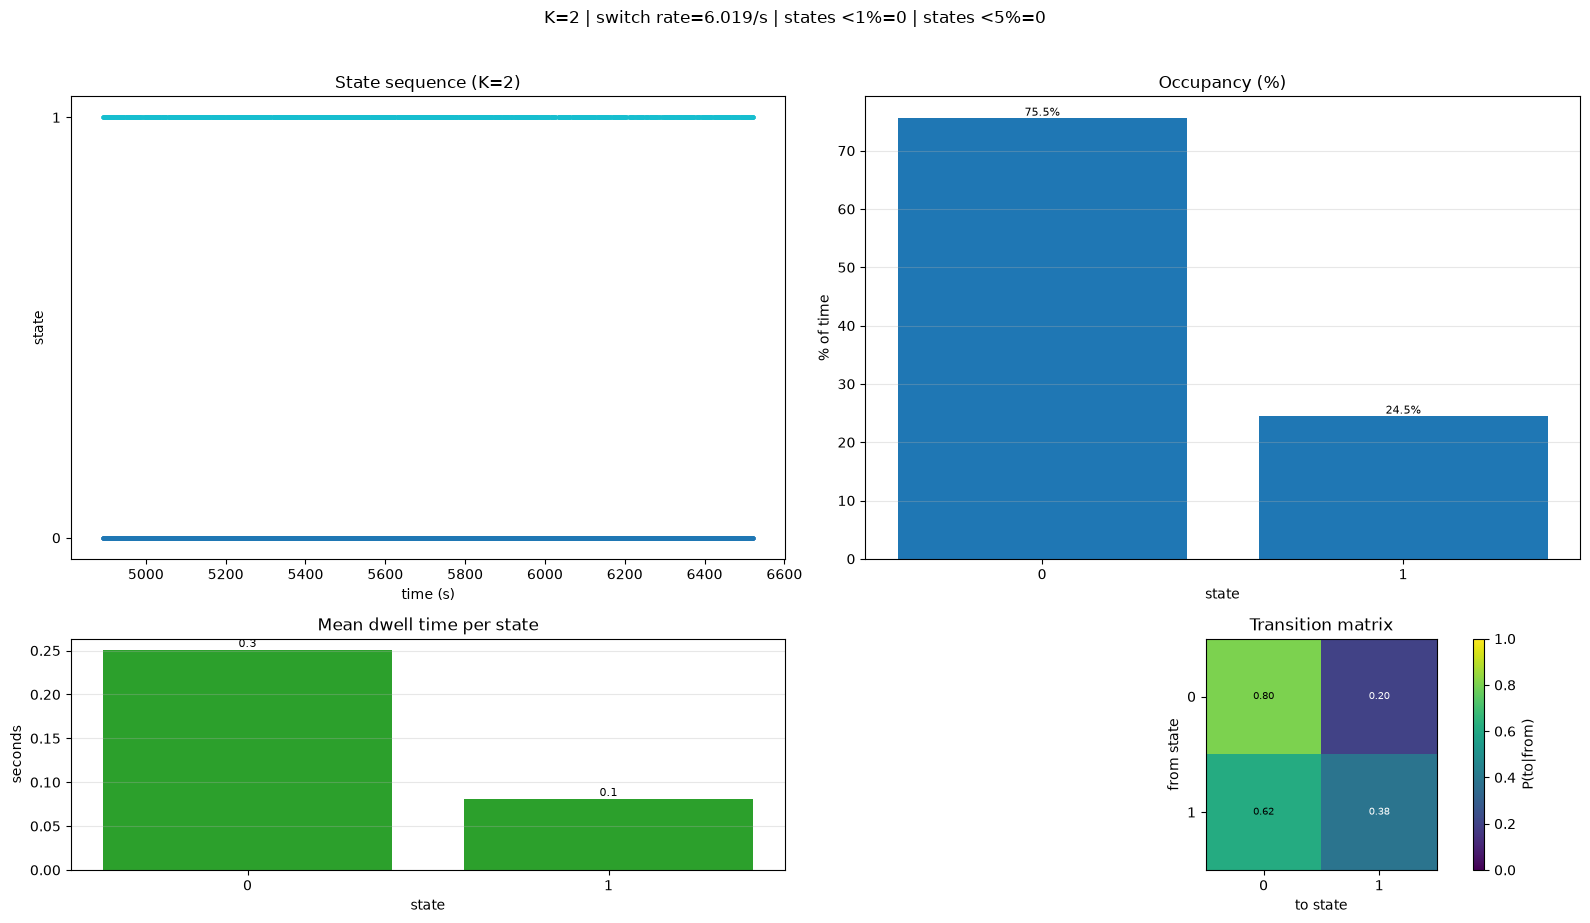

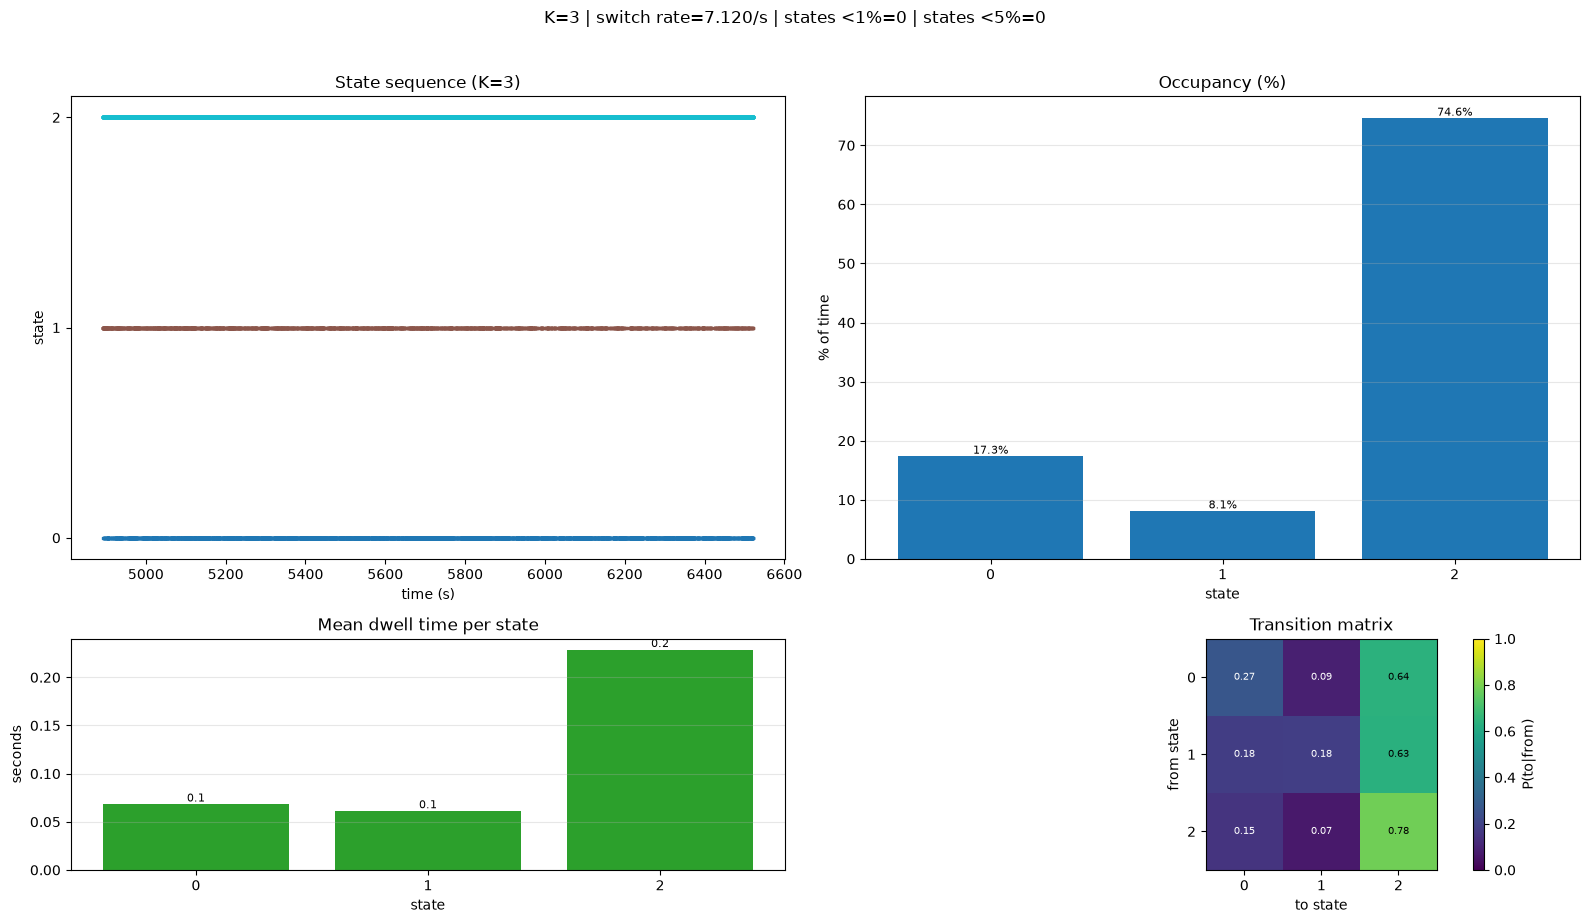

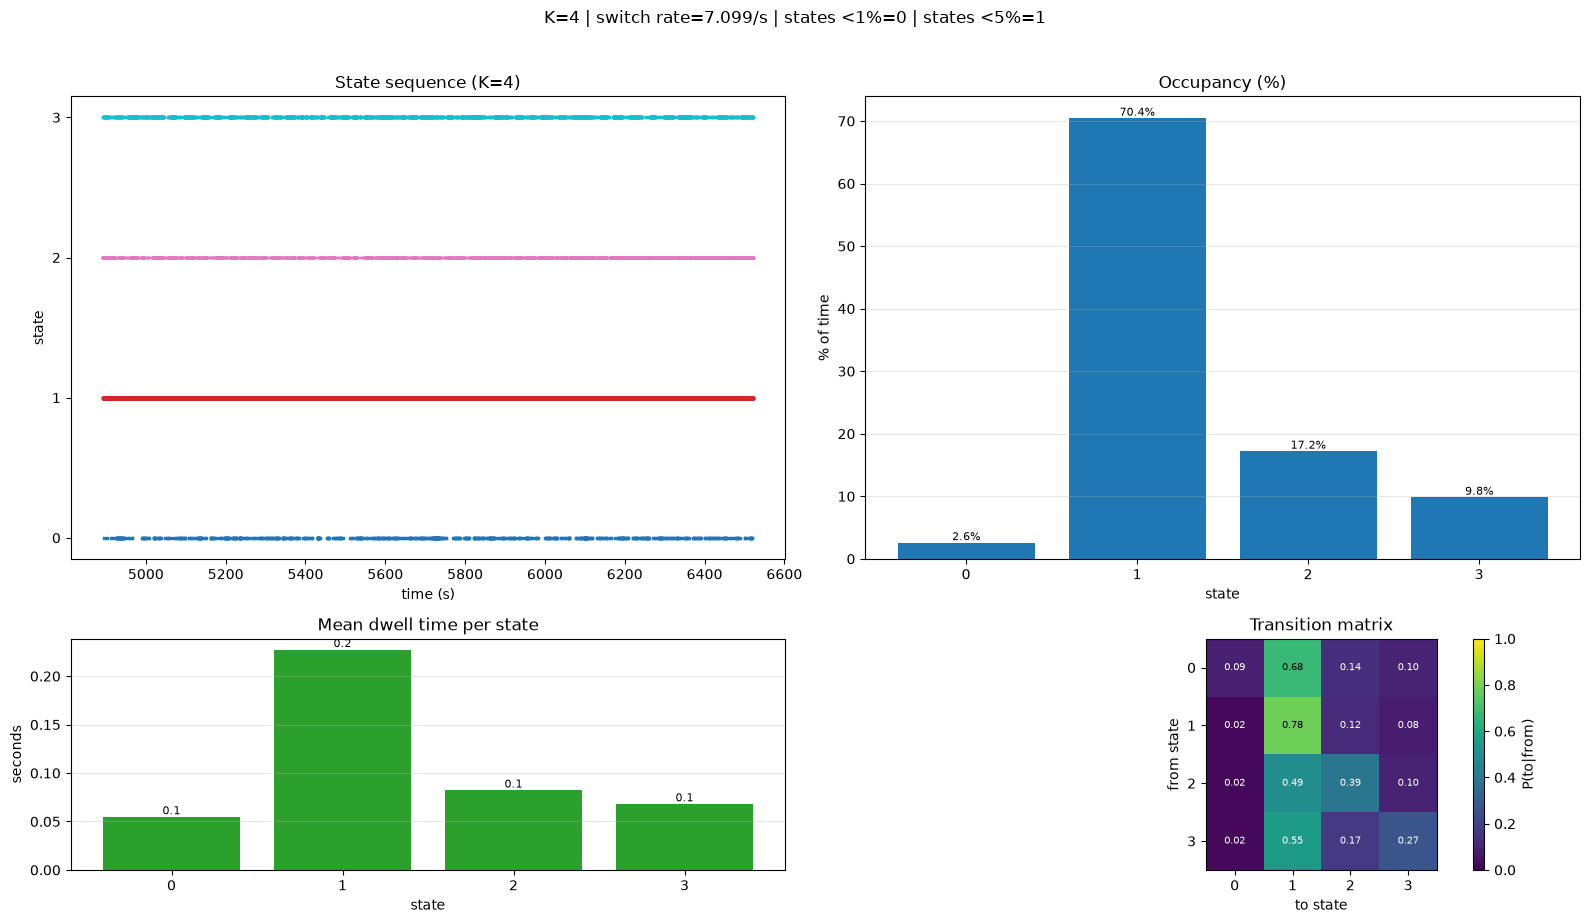

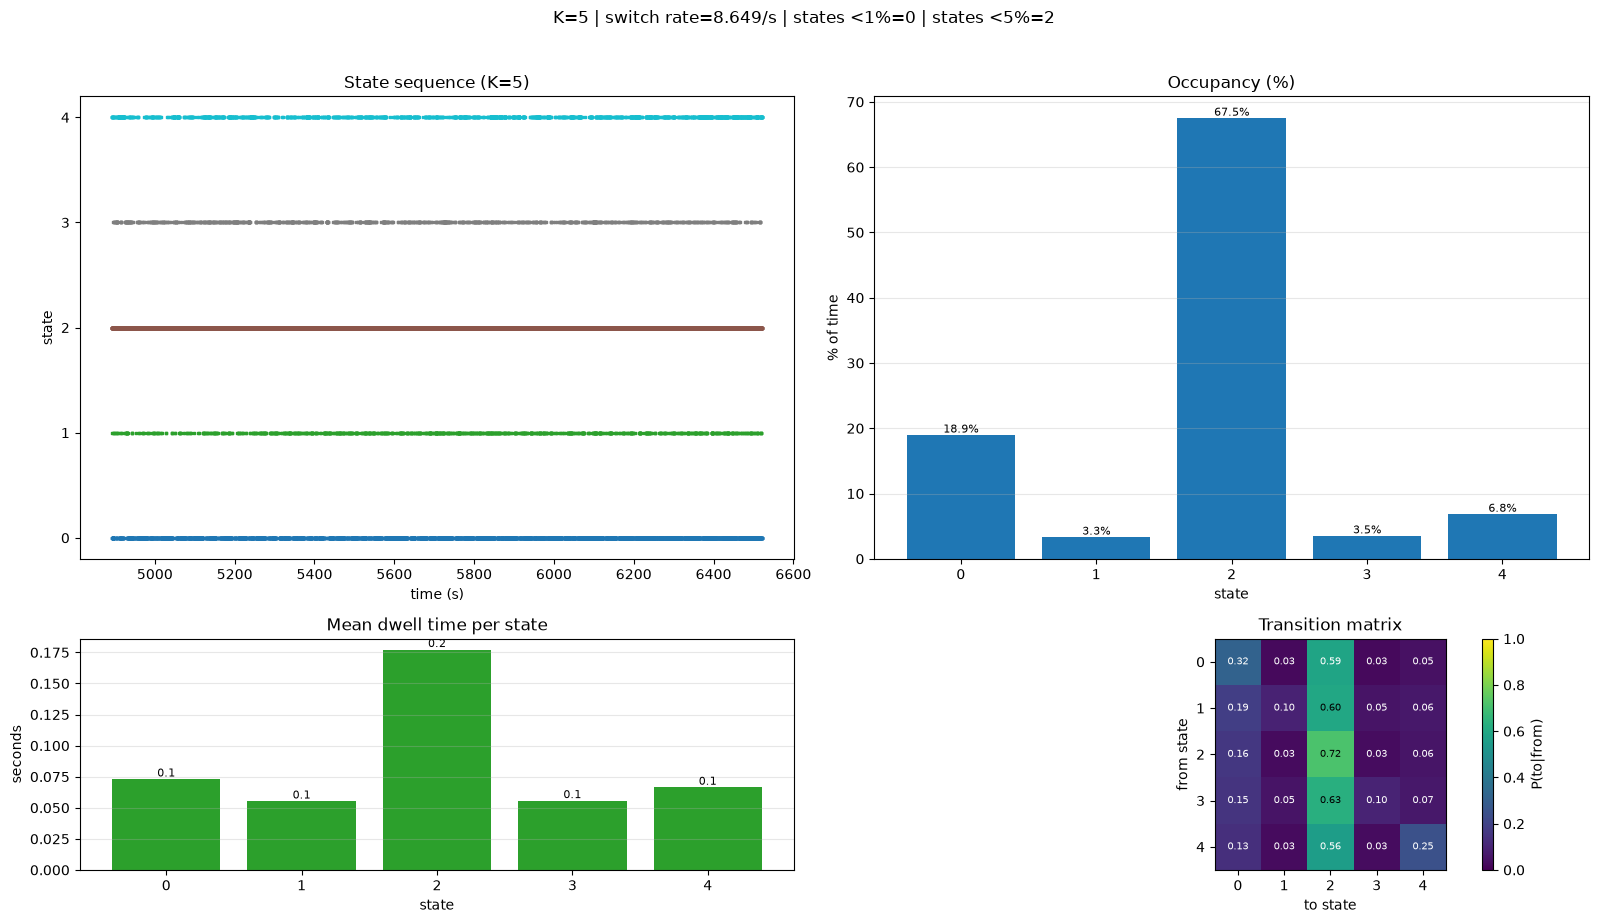

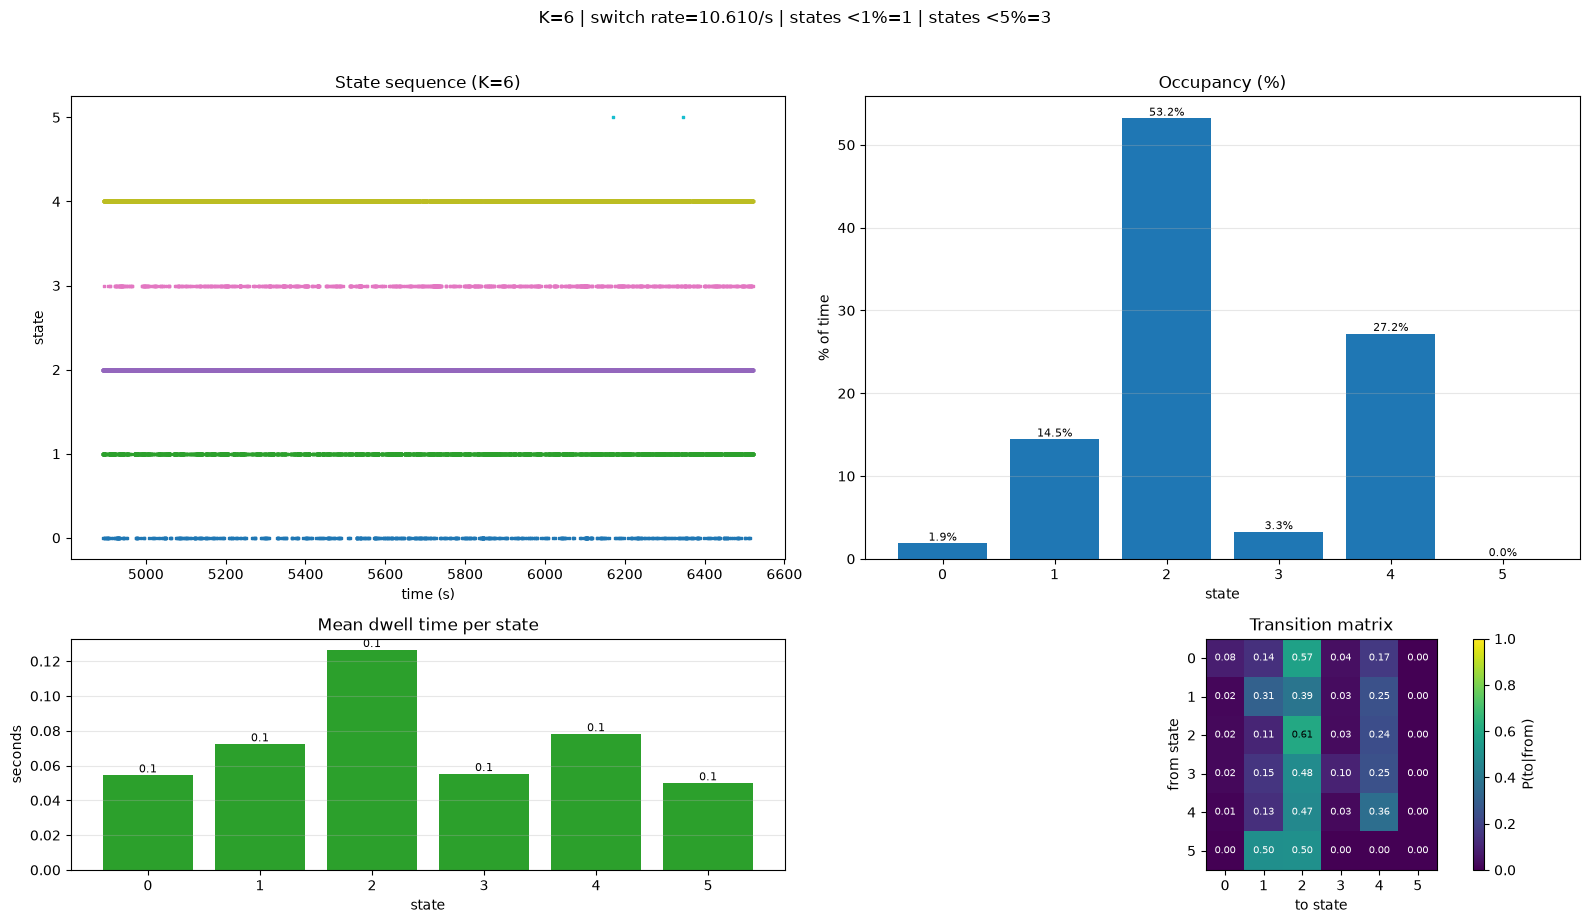

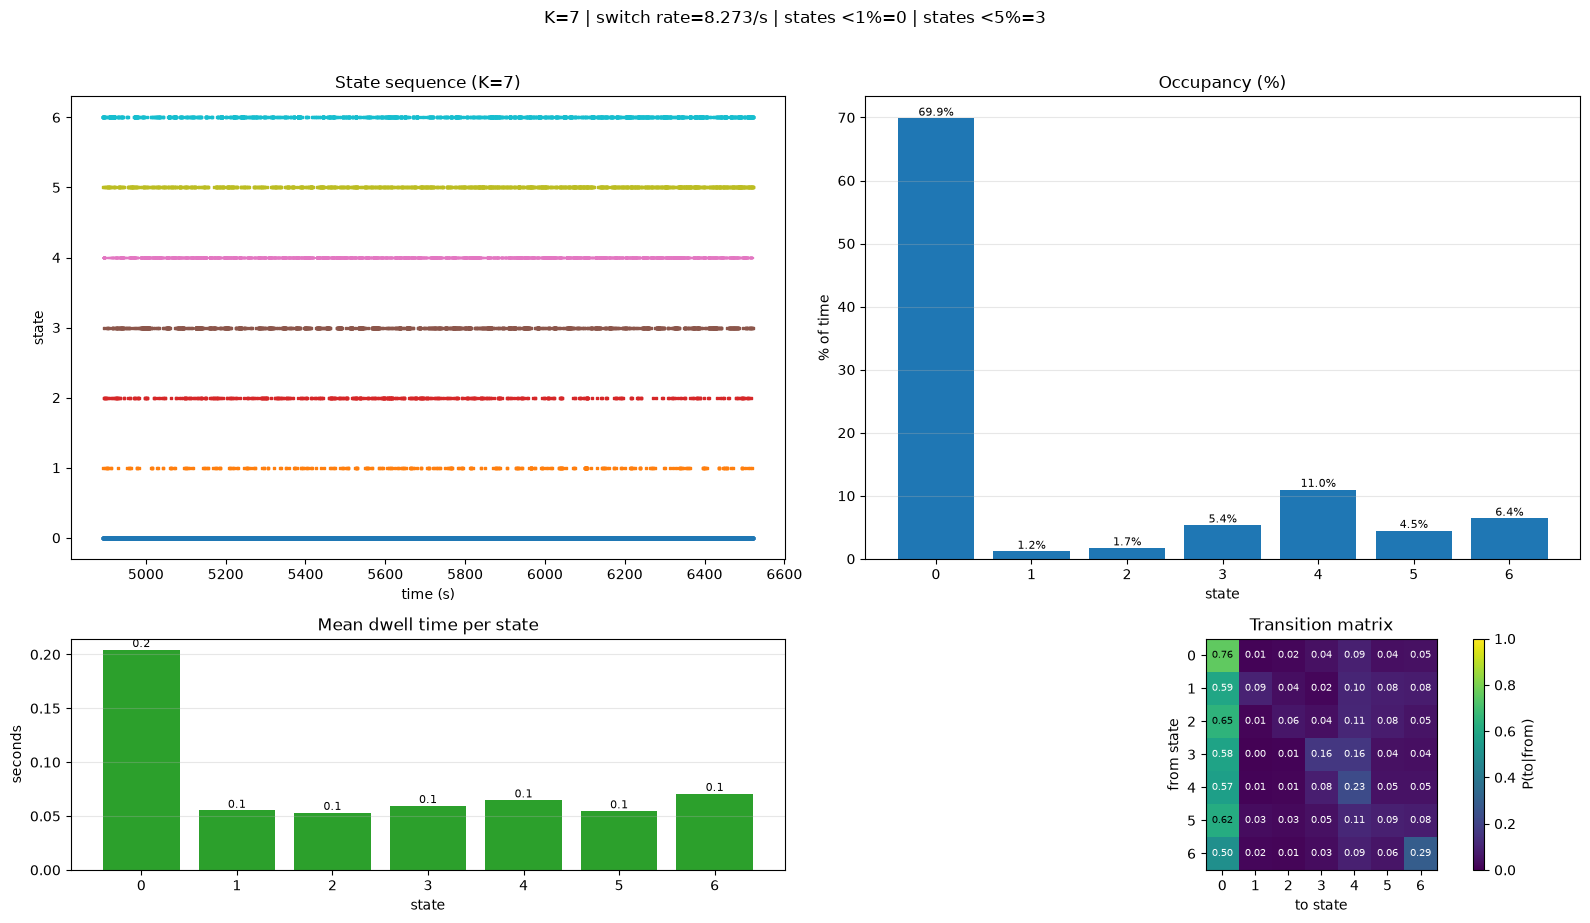

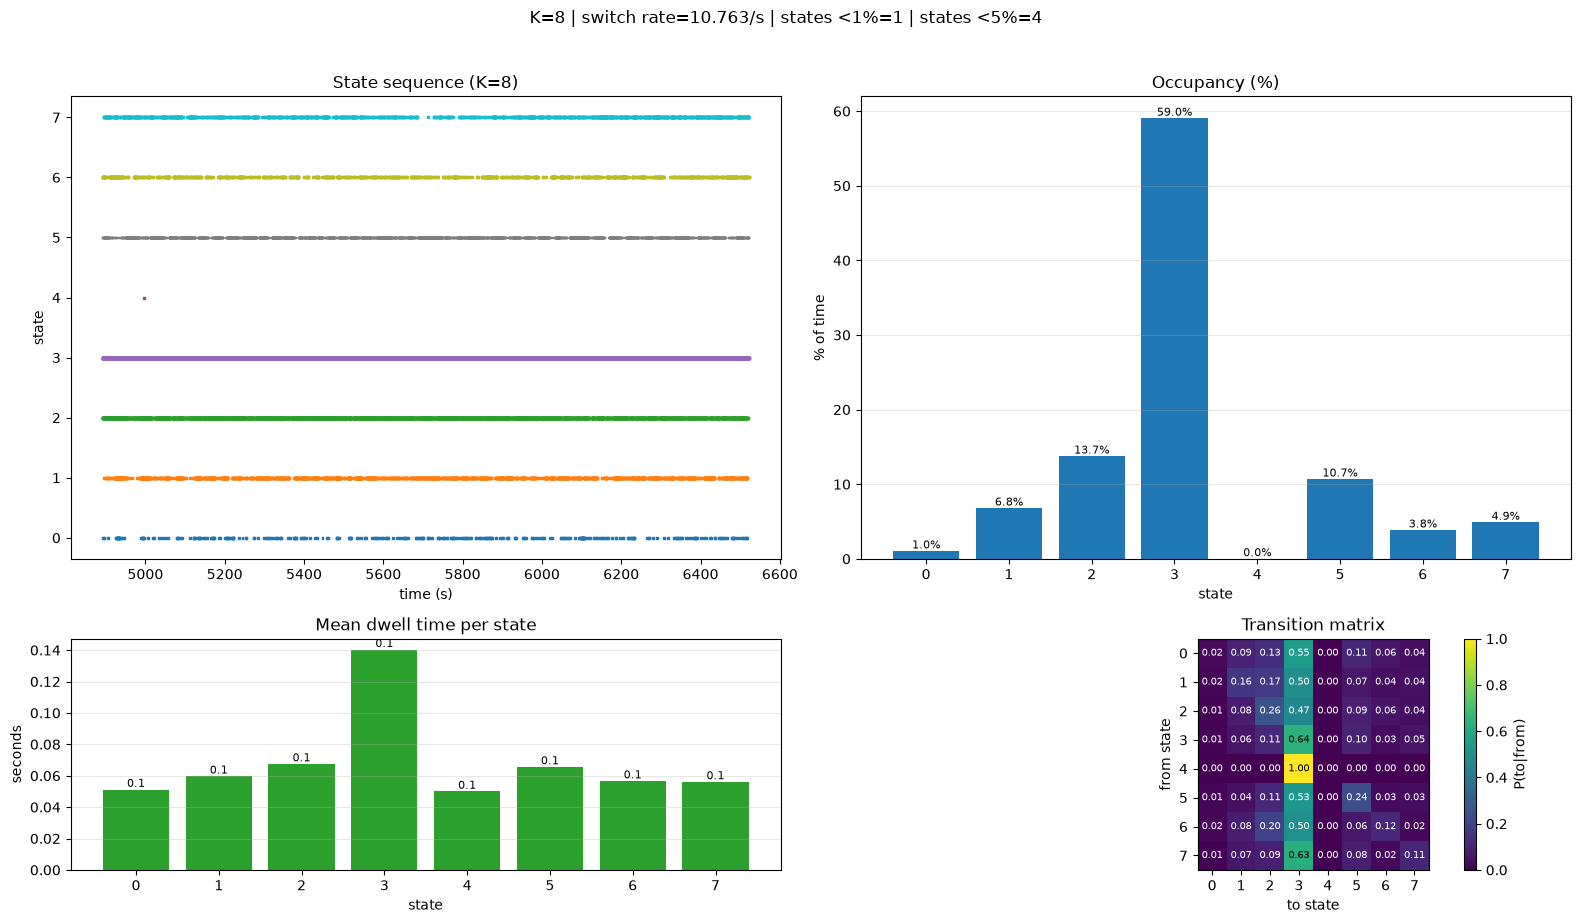

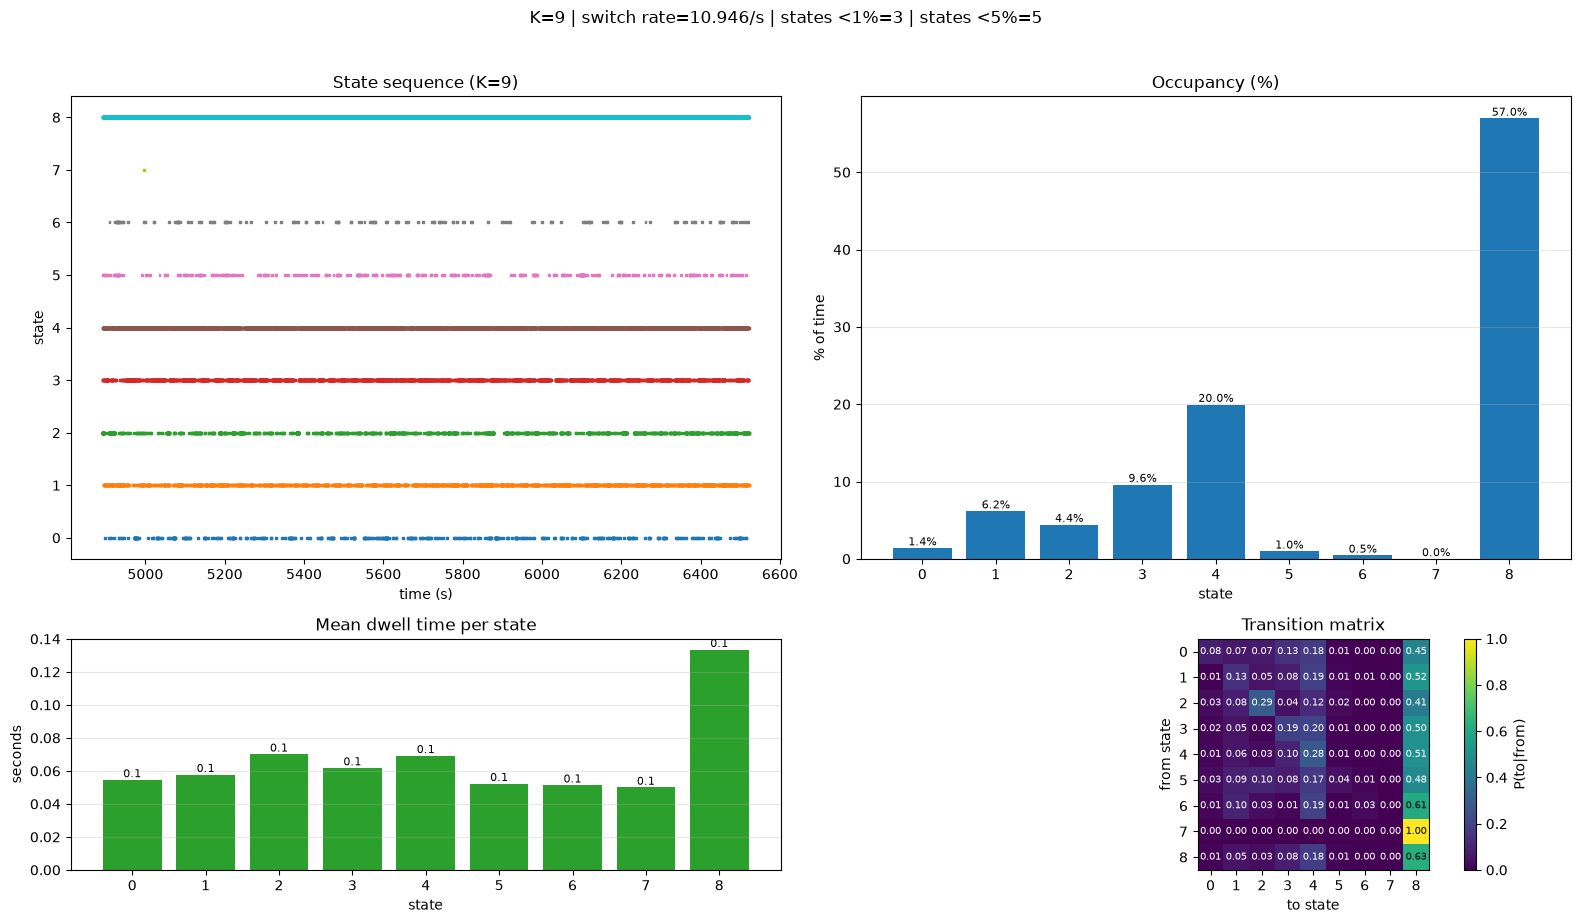

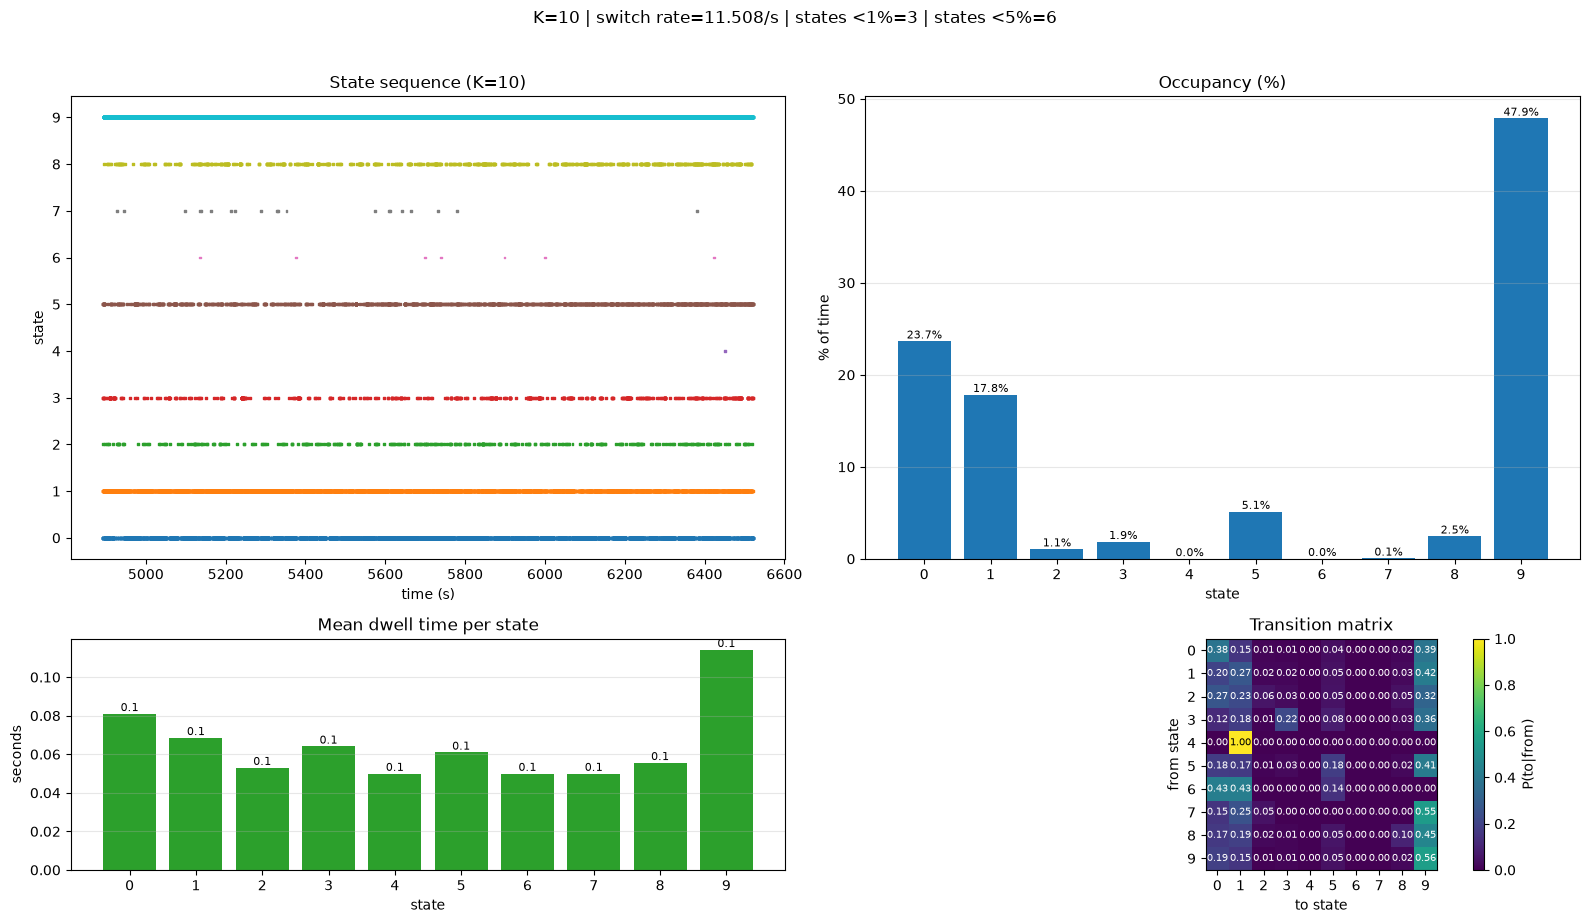

   n_states  switch_rate_per_s  min_occupancy_pct  median_occupancy_pct  \
8        10          11.508322           0.003071              2.166303   
7         9          10.946386           0.003071              4.433936   
6         8          10.763373           0.003071              5.832591   
5         7           8.273046           1.176037              5.352043   
4         6          10.610453           0.006141              8.855590   
3         5           8.648898           3.294746              6.804434   
2         4           7.098815           2.560875             13.506003   
1         3           7.120310           8.084871             17.348850   
0         2           6.019161          24.454202             50.000000   

   n_states_lt_1pct  n_states_lt_5pct  max_mean_dwell_s  min_mean_dwell_s  
8                 3                 6          0.114229          0.050000  
7                 3                 5          0.133456          0.050000  
6                 1  

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# assumes these already exist:
# hp_spatial_hmm_models, spike_matrix_z, bin_times_s, hmm_scores

dt = float(np.median(np.diff(bin_times_s))) if len(bin_times_s) > 1 else 1.0

def summarize_sequence(seq, n_states, dt):
    seq = np.asarray(seq, dtype=int)
    total = len(seq)

    occ_pct = np.array([(seq == s).mean() * 100 for s in range(n_states)])

    visit_counts = np.zeros(n_states, dtype=int)
    dwell_runs = {s: [] for s in range(n_states)}

    start = 0
    for i in range(1, total + 1):
        if i == total or seq[i] != seq[start]:
            s = seq[start]
            run_len = i - start
            dwell_runs[s].append(run_len * dt)
            visit_counts[s] += 1
            start = i

    mean_dwell = np.array([
        np.mean(dwell_runs[s]) if len(dwell_runs[s]) else 0.0
        for s in range(n_states)
    ])

    med_dwell = np.array([
        np.median(dwell_runs[s]) if len(dwell_runs[s]) else 0.0
        for s in range(n_states)
    ])

    switch_rate = np.sum(np.diff(seq) != 0) / ((total - 1) * dt) if total > 1 else 0.0

    return {
        "occupancy_pct": occ_pct,
        "visit_counts": visit_counts,
        "mean_dwell_s": mean_dwell,
        "median_dwell_s": med_dwell,
        "switch_rate_per_s": switch_rate,
    }

diagnostic_rows = []

for n_states in sorted(hp_spatial_hmm_models):
    hmm = hp_spatial_hmm_models[n_states]
    seq = hmm.predict(spike_matrix_z)
    T = hmm.transmat_

    diag = summarize_sequence(seq, n_states, dt)
    occ = diag["occupancy_pct"]
    mean_dwell = diag["mean_dwell_s"]
    visits = diag["visit_counts"]

    diagnostic_rows.append({
        "n_states": n_states,
        "switch_rate_per_s": diag["switch_rate_per_s"],
        "min_occupancy_pct": occ.min(),
        "median_occupancy_pct": np.median(occ),
        "n_states_lt_1pct": int((occ < 1.0).sum()),
        "n_states_lt_5pct": int((occ < 5.0).sum()),
        "max_mean_dwell_s": mean_dwell.max(),
        "min_mean_dwell_s": mean_dwell[mean_dwell > 0].min() if np.any(mean_dwell > 0) else 0.0,
    })

    fig, axes = plt.subplots(2, 2, figsize=(16, 9), gridspec_kw={"height_ratios": [2, 1]})

    # 1) temporal state sequence
    axes[0, 0].scatter(bin_times_s, seq, c=seq, cmap="tab10", s=2, marker="s")
    axes[0, 0].set(
        title=f"State sequence (K={n_states})",
        xlabel="time (s)",
        ylabel="state",
        yticks=range(n_states),
    )

    # 2) occupancy
    bars = axes[0, 1].bar(np.arange(n_states), occ, color="tab:blue")
    axes[0, 1].set(
        title="Occupancy (%)",
        xlabel="state",
        ylabel="% of time",
        xticks=range(n_states),
    )
    axes[0, 1].grid(alpha=0.3, axis="y")
    for b, v in zip(bars, occ):
        axes[0, 1].text(b.get_x() + b.get_width()/2, b.get_height(), f"{v:.1f}%",
                        ha="center", va="bottom", fontsize=8)

    # 3) dwell times
    bars = axes[1, 0].bar(np.arange(n_states), mean_dwell, color="tab:green")
    axes[1, 0].set(
        title="Mean dwell time per state",
        xlabel="state",
        ylabel="seconds",
        xticks=range(n_states),
    )
    axes[1, 0].grid(alpha=0.3, axis="y")
    for b, v in zip(bars, mean_dwell):
        axes[1, 0].text(b.get_x() + b.get_width()/2, b.get_height(), f"{v:.1f}",
                        ha="center", va="bottom", fontsize=8)

    # 4) transition matrix
    im = axes[1, 1].imshow(T, cmap="viridis", vmin=0, vmax=1)
    axes[1, 1].set(
        title="Transition matrix",
        xlabel="to state",
        ylabel="from state",
        xticks=range(n_states),
        yticks=range(n_states),
    )
    for i in range(n_states):
        for j in range(n_states):
            axes[1, 1].text(
                j, i, f"{T[i, j]:.2f}",
                ha="center", va="center",
                color="w" if T[i, j] < 0.6 else "k",
                fontsize=7,
            )
    fig.colorbar(im, ax=axes[1, 1], label="P(to|from)")

    fig.suptitle(
        f"K={n_states} | switch rate={diag['switch_rate_per_s']:.3f}/s | "
        f"states <1%={int((occ < 1).sum())} | states <5%={int((occ < 5).sum())}",
        y=1.02
    )
    plt.tight_layout()
    plt.show()

summary = pd.DataFrame(diagnostic_rows).sort_values("n_states", ascending=False)
print(summary)

In [11]:
from dandi.dandiapi import DandiAPIClient
from pathlib import Path
import pandas as pd
import pynapple as nap
import gc

def extract_units_metadata_from_asset(asset, download_dir):
    local_path = download_dir / asset.path
    local_path.parent.mkdir(parents=True, exist_ok=True)

    if not local_path.exists():
        asset.download(local_path)

    sess_tmp = nap.load_file(str(local_path))

    # keep only spatial-nav / maze sessions
    if "Position" not in sess_tmp.keys():
        del sess_tmp
        gc.collect()
        return None

    units_tmp = sess_tmp["units"].metadata.copy().reset_index(drop=False)
    units_tmp = units_tmp.rename(columns={"index": "unit_id"})
    units_tmp["session"] = Path(asset.path).stem

    # keep only the columns you care about
    feature_cols = [
        "rate", "cell_type", "cell_area", "firing_rate", "ab_ratio",
        "burstIndex_Mizuseki2012", "cv2", "maxWaveformCh", "troughToPeak",
        "acg_tau_decay", "acg_tau_rise", "thetaModulationIndex",
        "x_position_probe", "y_position_probe"
    ]
    keep = [c for c in feature_cols if c in units_tmp.columns]
    out = units_tmp[["session", "unit_id"] + keep].copy()

    # clear temporary session data immediately
    del sess_tmp, units_tmp
    gc.collect()

    return out

tables = []

with DandiAPIClient() as client:
    dandiset = client.get_dandiset(DANDISET_ID, VERSION_ID)

    for asset in dandiset.get_assets_with_path_prefix(SUBJECT, order="path"):
        if "behavior+ecephys" not in asset.path:
            continue

        tbl = extract_units_metadata_from_asset(asset, DOWNLOAD_DIR)
        if tbl is not None and len(tbl):
            tables.append(tbl)

unit_df = pd.concat(tables, ignore_index=True)

print("Combined units table:", unit_df.shape)
print(unit_df["session"].value_counts())

Combined units table: (1104, 16)
session
sub-M01_ses-20240312T100000_behavior+ecephys    430
sub-M01_ses-20240313T100000_behavior+ecephys    240
sub-M01_ses-20240314T100000_behavior+ecephys    222
sub-M01_ses-20240318T100000_behavior+ecephys    212
Name: count, dtype: int64


In [12]:
from dandi.dandiapi import DandiAPIClient
from pathlib import Path, PurePosixPath
import pandas as pd
import pynapple as nap
import gc
import re

# -----------------------------
# config
# -----------------------------
DANDISET_ID = "001695"
VERSION_ID = "0.260319.2023"
DOWNLOAD_DIR = Path("../../storage/dandi_downloads").resolve()
DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)

# If you want ALL subjects (including sub-NN-syn-*), keep as None.
# If you want only the main mouse subjects, set e.g. subject_regex = r"^sub-M\d+$"
subject_regex = None  # example: r"^sub-M\d+$"

feature_cols = [
    "rate", "cell_type", "cell_area", "firing_rate", "ab_ratio",
    "burstIndex_Mizuseki2012", "cv2", "maxWaveformCh", "troughToPeak",
    "acg_tau_decay", "acg_tau_rise", "thetaModulationIndex",
    "x_position_probe", "y_position_probe"
]

def parse_subject_session_from_path(asset_path: str):
    p = PurePosixPath(asset_path)
    parts = p.parts
    subject = next((x for x in parts if x.startswith("sub-")), None)
    session = next((x for x in parts if x.startswith("ses-")), None)
    stem = p.stem
    session_key = f"{subject}_{session}" if subject and session else f"{subject}_{stem}"
    return subject, session, session_key, stem

def extract_units_metadata_from_asset(asset, download_dir):
    subject, session, session_key, stem = parse_subject_session_from_path(asset.path)

    local_path = download_dir / asset.path
    local_path.parent.mkdir(parents=True, exist_ok=True)
    if not local_path.exists():
        asset.download(local_path)

    sess_tmp = nap.load_file(str(local_path))

    # keep only spatial-navigation sessions that have Position
    if "Position" not in sess_tmp.keys() or "units" not in sess_tmp.keys():
        del sess_tmp
        gc.collect()
        return None

    units_tmp = sess_tmp["units"].metadata.copy().reset_index(drop=False).rename(columns={"index": "unit_id"})
    units_tmp["subject"] = subject
    units_tmp["session"] = session_key
    units_tmp["asset_stem"] = stem
    units_tmp["asset_path"] = asset.path

    keep = [c for c in feature_cols if c in units_tmp.columns]
    out = units_tmp[["subject", "session", "unit_id", "asset_stem", "asset_path"] + keep].copy()

    del sess_tmp, units_tmp
    gc.collect()
    return out

# -----------------------------
# 1) discover candidate assets across ALL subjects
# -----------------------------
with DandiAPIClient() as client:
    dandiset = client.get_dandiset(DANDISET_ID, VERSION_ID)
    all_assets = list(dandiset.get_assets(order="path"))

candidate_rows = []
for a in all_assets:
    if "behavior+ecephys" not in a.path:
        continue
    if not a.path.endswith(".nwb"):
        continue

    subject, session, session_key, stem = parse_subject_session_from_path(a.path)
    if subject_regex is not None and (subject is None or re.match(subject_regex, subject) is None):
        continue

    candidate_rows.append({
        "subject": subject,
        "session_tag": session,
        "session_key": session_key,
        "asset_stem": stem,
        "asset_path": a.path,
        "size_mb": round(a.size / (1024**2), 2) if a.size is not None else None
    })

candidate_df = pd.DataFrame(candidate_rows).sort_values(["subject", "session_tag", "asset_path"]).reset_index(drop=True)

print(f"Candidate behavior+ecephys NWBs: {len(candidate_df)}")
print("Subjects found:", sorted(candidate_df["subject"].dropna().unique().tolist()))
print("\nSessions per subject:")
print(candidate_df.groupby("subject")["session_key"].nunique().sort_index())
print("\nFirst rows of planned pulls:")
print(candidate_df[["subject", "session_tag", "asset_path", "size_mb"]].head(30))

# -----------------------------
# 2) pull units metadata
# -----------------------------
tables = []
pull_log = []

# recreate client scope for robust API usage
with DandiAPIClient() as client:
    dandiset = client.get_dandiset(DANDISET_ID, VERSION_ID)
    # index by path so we pull exactly from candidate list
    asset_map = {a.path: a for a in dandiset.get_assets(order="path")}

    for _, row in candidate_df.iterrows():
        apath = row["asset_path"]
        asset = asset_map[apath]

        try:
            tbl = extract_units_metadata_from_asset(asset, DOWNLOAD_DIR)
            if tbl is None or len(tbl) == 0:
                pull_log.append((apath, "SKIP_NO_POSITION_OR_UNITS", 0))
            else:
                tables.append(tbl)
                pull_log.append((apath, "OK", len(tbl)))
        except Exception as e:
            pull_log.append((apath, f"ERROR: {e}", 0))

if len(tables) == 0:
    raise RuntimeError("No unit tables were extracted. Check candidate_df and logs.")

unit_df = pd.concat(tables, ignore_index=True)

# -----------------------------
# 3) de-duplicate to avoid double counting
# -----------------------------
# Primary de-dup key: subject + session + unit_id
# (If the same session was encountered twice, this removes duplicates.)
before = len(unit_df)
unit_df = unit_df.drop_duplicates(subset=["subject", "session", "unit_id"]).reset_index(drop=True)
after = len(unit_df)

print(f"\nunit_df rows before dedup: {before}")
print(f"unit_df rows after  dedup: {after}")
print(f"Removed duplicates: {before - after}")

log_df = pd.DataFrame(pull_log, columns=["asset_path", "status", "n_units"]).sort_values("asset_path")
print("\nPull log summary:")
print(log_df["status"].value_counts())
print("\nAny errors/skips:")
print(log_df[log_df["status"] != "OK"].head(50))

print("\nFinal unit counts by subject:")
print(unit_df.groupby("subject")["unit_id"].count().sort_index())

print("\nFinal session counts by subject:")
print(unit_df.groupby("subject")["session"].nunique().sort_index())

print("\nPreview:")
print(unit_df.head())

Candidate behavior+ecephys NWBs: 15
Subjects found: ['sub-M01', 'sub-M02', 'sub-M03', 'sub-M05']

Sessions per subject:
subject
sub-M01    4
sub-M02    4
sub-M03    4
sub-M05    3
Name: session_key, dtype: int64

First rows of planned pulls:
    subject session_tag                                         asset_path  \
0   sub-M01        None  sub-M01/sub-M01_ses-20240312T100000_behavior+e...   
1   sub-M01        None  sub-M01/sub-M01_ses-20240313T100000_behavior+e...   
2   sub-M01        None  sub-M01/sub-M01_ses-20240314T100000_behavior+e...   
3   sub-M01        None  sub-M01/sub-M01_ses-20240318T100000_behavior+e...   
4   sub-M02        None  sub-M02/sub-M02_ses-20240312T100000_behavior+e...   
5   sub-M02        None  sub-M02/sub-M02_ses-20240313T100000_behavior+e...   
6   sub-M02        None  sub-M02/sub-M02_ses-20240314T100000_behavior+e...   
7   sub-M02        None  sub-M02/sub-M02_ses-20240318T100000_behavior+e...   
8   sub-M03        None  sub-M03/sub-M03_ses-20240621T10

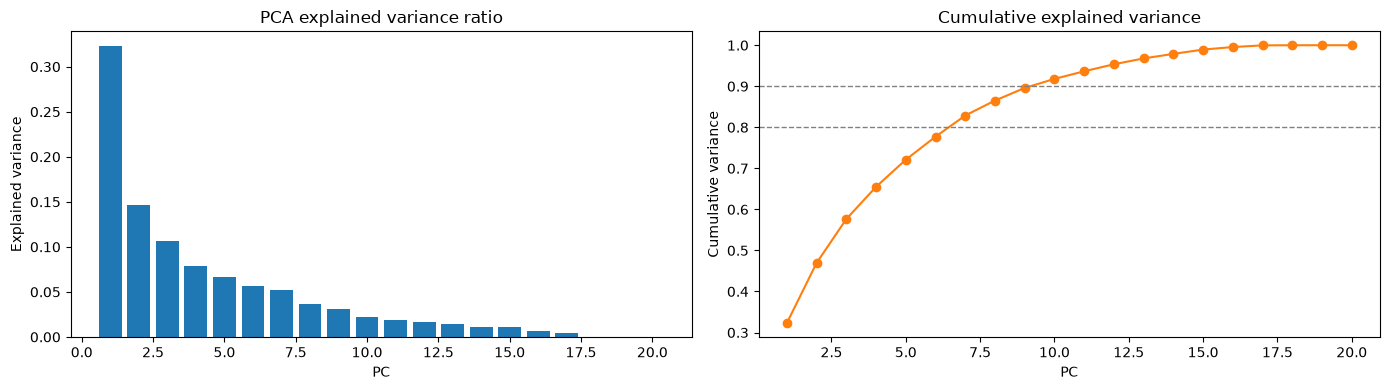

    PC  explained_var  cumulative_var
0    1       0.323117        0.323117
1    2       0.146416        0.469533
2    3       0.106958        0.576491
3    4       0.078480        0.654971
4    5       0.066138        0.721109
5    6       0.056028        0.777138
6    7       0.051623        0.828761
7    8       0.036427        0.865188
8    9       0.030719        0.895908
9   10       0.022044        0.917952
10  11       0.018554        0.936506
11  12       0.017066        0.953571
12  13       0.014279        0.967851
13  14       0.011055        0.978905
14  15       0.010507        0.989412
15  16       0.006144        0.995557
16  17       0.004097        0.999653
17  18       0.000299        0.999952
18  19       0.000046        0.999999
19  20       0.000001        1.000000
Using top 6 PCs for clustering
Best K by silhouette: 2


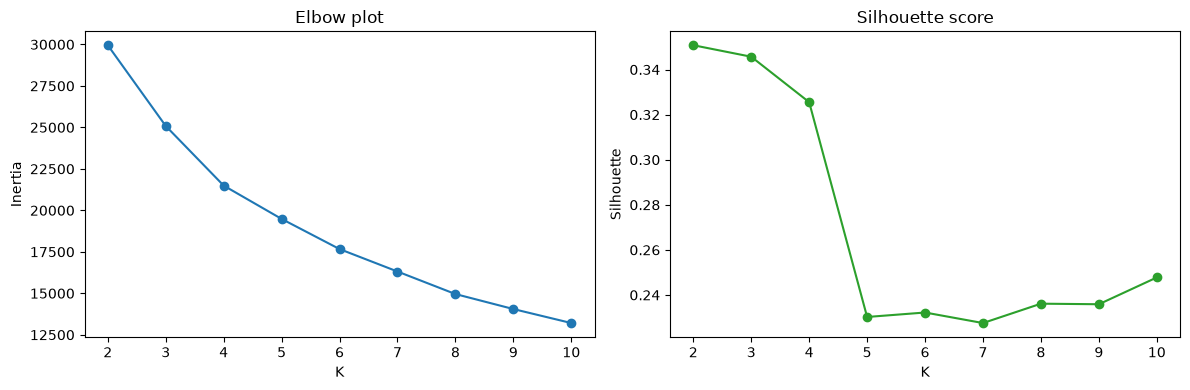

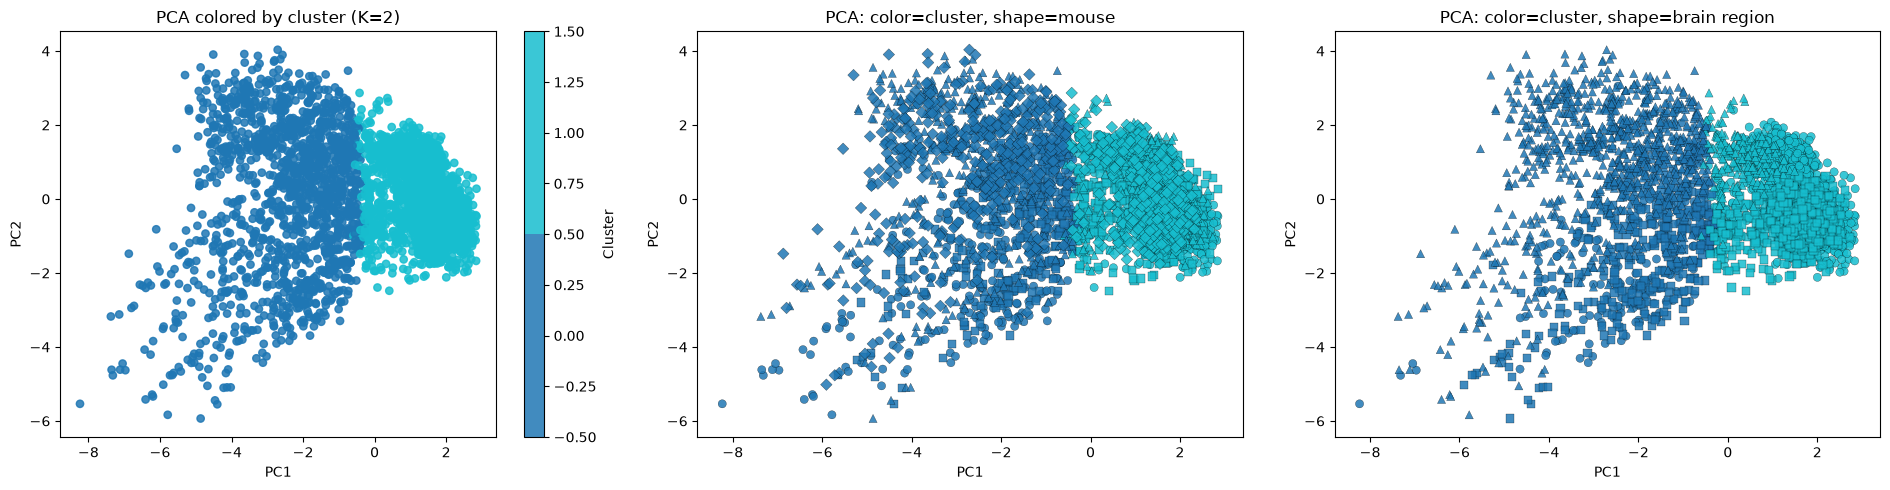

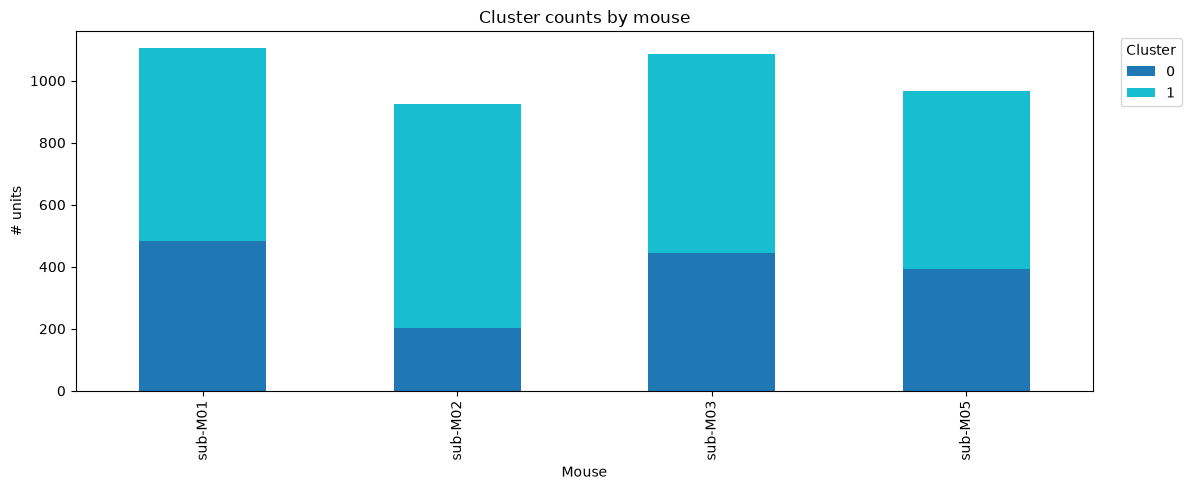

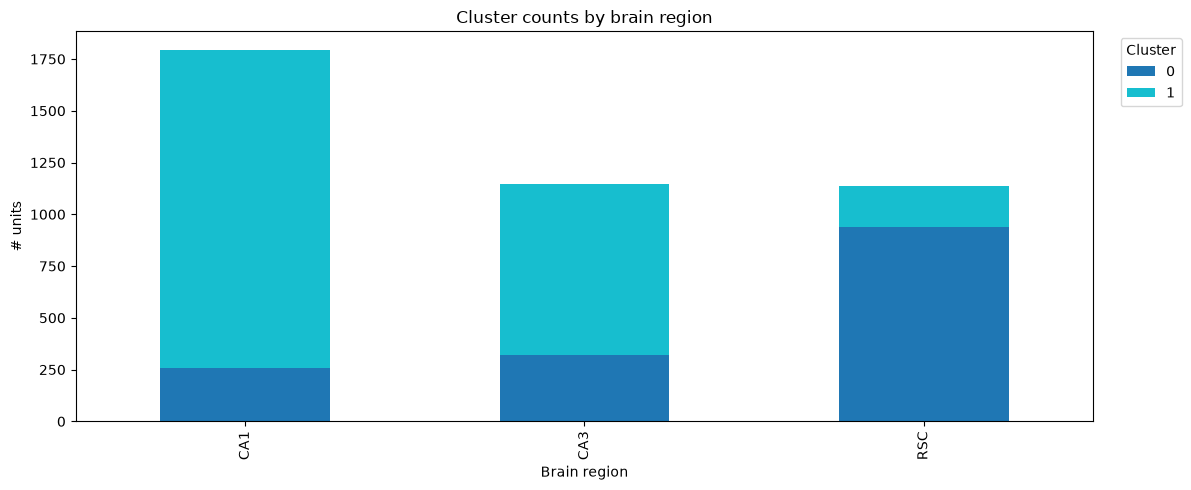

                                             session    mouse  cluster  \
0  sub-M01_sub-M01_ses-20240312T100000_behavior+e...  sub-M01        0   
1  sub-M01_sub-M01_ses-20240312T100000_behavior+e...  sub-M01        0   
2  sub-M01_sub-M01_ses-20240312T100000_behavior+e...  sub-M01        0   
3  sub-M01_sub-M01_ses-20240312T100000_behavior+e...  sub-M01        1   
4  sub-M01_sub-M01_ses-20240312T100000_behavior+e...  sub-M01        1   

            cell_type cell_area  
0    Wide Interneuron       RSC  
1  Narrow Interneuron       CA1  
2      Pyramidal Cell       RSC  
3      Pyramidal Cell       RSC  
4      Pyramidal Cell       RSC  
              rate  firing_rate  ab_ratio  burstIndex_Mizuseki2012       cv2  \
cluster                                                                        
0        11.003481    11.009159  0.201391                 0.093756  0.870432   
1         1.155158     1.156974 -0.332173                 0.147018  1.079057   

         maxWaveformCh  trough

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# ------------------------------------------------------------
# 0) Setup
# ------------------------------------------------------------
df = unit_df.copy()

# derive mouse from session name if needed
if "mouse" not in df.columns:
    df["mouse"] = df["session"].astype(str).str.extract(r"(sub-[A-Za-z0-9]+)", expand=False)
    df["mouse"] = df["mouse"].fillna(df["session"].astype(str))

feature_cols = [
    "rate", "cell_type", "cell_area", "firing_rate", "ab_ratio",
    "burstIndex_Mizuseki2012", "cv2", "maxWaveformCh", "troughToPeak",
    "acg_tau_decay", "acg_tau_rise", "thetaModulationIndex",
    "x_position_probe", "y_position_probe"
]

cat_cols = [c for c in ["cell_type", "cell_area", "mouse"] if c in df.columns]
num_cols = [c for c in feature_cols if c in df.columns and c not in cat_cols]

X_df = df[num_cols + cat_cols].copy()

# ------------------------------------------------------------
# 1) Preprocess: z-score numeric, one-hot categorical
# ------------------------------------------------------------
preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
        ]), num_cols),
        ("cat", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]), cat_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

X = preprocess.fit_transform(X_df)

# ------------------------------------------------------------
# 2) PCA
# ------------------------------------------------------------
n_pcs_max = min(20, X.shape[1])
pca = PCA(n_components=n_pcs_max, random_state=0)
Z = pca.fit_transform(X)

explained = pca.explained_variance_ratio_
cumexplained = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(np.arange(1, len(explained) + 1), explained, color="tab:blue")
axes[0].set(title="PCA explained variance ratio", xlabel="PC", ylabel="Explained variance")

axes[1].plot(np.arange(1, len(cumexplained) + 1), cumexplained, "o-", color="tab:orange")
axes[1].axhline(0.8, ls="--", color="gray", lw=1)
axes[1].axhline(0.9, ls="--", color="gray", lw=1)
axes[1].set(title="Cumulative explained variance", xlabel="PC", ylabel="Cumulative variance")
plt.tight_layout()
plt.show()

print(pd.DataFrame({
    "PC": np.arange(1, len(explained) + 1),
    "explained_var": explained,
    "cumulative_var": cumexplained
}))

# choose how many PCs to cluster on
# adjust this after looking at the elbow plot
N_PCS_USE = min(6, Z.shape[1])
Z_use = Z[:, :N_PCS_USE]

print(f"Using top {N_PCS_USE} PCs for clustering")

# ------------------------------------------------------------
# 3) KMeans sweep + silhouette
# ------------------------------------------------------------
k_range = range(2, min(11, len(df)))
inertias = []
silhs = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=0, n_init=20)
    labels = km.fit_predict(Z_use)
    inertias.append(km.inertia_)
    silhs.append(silhouette_score(Z_use, labels))

best_k = int(list(k_range)[int(np.argmax(silhs))])
print(f"Best K by silhouette: {best_k}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_range), inertias, "o-", color="tab:blue")
axes[0].set(title="Elbow plot", xlabel="K", ylabel="Inertia")

axes[1].plot(list(k_range), silhs, "o-", color="tab:green")
axes[1].set(title="Silhouette score", xlabel="K", ylabel="Silhouette")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4) Final KMeans on top PCs
# ------------------------------------------------------------
kmeans = KMeans(n_clusters=best_k, random_state=0, n_init=20)
df["cluster"] = kmeans.fit_predict(Z_use)
df["PC1"] = Z_use[:, 0]
df["PC2"] = Z_use[:, 1] if Z_use.shape[1] > 1 else 0.0

# ------------------------------------------------------------
# 5) 2D PCA visualization instead of UMAP
# ------------------------------------------------------------
df["PC1"] = Z_use[:, 0]
df["PC2"] = Z_use[:, 1] if Z_use.shape[1] > 1 else 0.0
# Ensure plotting helpers exist
cluster_ids = sorted(df["cluster"].unique())
cluster_cmap = plt.get_cmap("tab10", len(cluster_ids))
cluster_norm = plt.Normalize(vmin=min(cluster_ids) - 0.5, vmax=max(cluster_ids) + 0.5)

marker_cycle = ["o", "s", "^", "D", "P", "X", "v", "<", ">", "*", "h", "p"]

if "mouse" not in df.columns:
    df["mouse"] = df["session"].astype(str).str.extract(r"(sub-[A-Za-z0-9]+)", expand=False).fillna(df["session"].astype(str))
mouse_levels = sorted(df["mouse"].dropna().unique())
mouse_markers = {m: marker_cycle[i % len(marker_cycle)] for i, m in enumerate(mouse_levels)}

region_col = "cell_area" if "cell_area" in df.columns else None
region_levels = sorted(df[region_col].dropna().unique()) if region_col else []
region_markers = {r: marker_cycle[i % len(marker_cycle)] for i, r in enumerate(region_levels)}


fig, axes = plt.subplots(1, 3, figsize=(19, 5))

# A) colored by cluster
sc = axes[0].scatter(df["PC1"], df["PC2"], c=df["cluster"], cmap=cluster_cmap, norm=cluster_norm, s=28, alpha=0.85)
axes[0].set(title=f"PCA colored by cluster (K={best_k})", xlabel="PC1", ylabel="PC2")
plt.colorbar(sc, ax=axes[0], label="Cluster")

# B) color by cluster, shape by mouse
for m in mouse_levels:
    sub = df[df["mouse"] == m]
    axes[1].scatter(sub["PC1"], sub["PC2"], c=sub["cluster"], cmap=cluster_cmap, norm=cluster_norm,
                    marker=mouse_markers[m], s=35, alpha=0.85, edgecolor="k", linewidth=0.2)
axes[1].set(title="PCA: color=cluster, shape=mouse", xlabel="PC1", ylabel="PC2")

# C) color by cluster, shape by brain region
if region_col is not None:
    for r in region_levels:
        sub = df[df[region_col] == r]
        axes[2].scatter(sub["PC1"], sub["PC2"], c=sub["cluster"], cmap=cluster_cmap, norm=cluster_norm,
                        marker=region_markers[r], s=35, alpha=0.85, edgecolor="k", linewidth=0.2)
    axes[2].set(title="PCA: color=cluster, shape=brain region", xlabel="PC1", ylabel="PC2")
else:
    axes[2].axis("off")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6) Cluster count bars by mouse and by brain region
# ------------------------------------------------------------
mouse_ct = pd.crosstab(df["mouse"], df["cluster"])
fig, ax = plt.subplots(figsize=(12, 5))
mouse_ct.plot(kind="bar", stacked=True, ax=ax, colormap="tab10")
ax.set(title="Cluster counts by mouse", xlabel="Mouse", ylabel="# units")
ax.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

if region_col is not None:
    region_ct = pd.crosstab(df[region_col], df["cluster"])
    fig, ax = plt.subplots(figsize=(12, 5))
    region_ct.plot(kind="bar", stacked=True, ax=ax, colormap="tab10")
    ax.set(title="Cluster counts by brain region", xlabel="Brain region", ylabel="# units")
    ax.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# 8) Optional: cluster summary table
# ------------------------------------------------------------
summary = df.groupby("cluster")[num_cols].mean(numeric_only=True)
print(df[["session", "mouse", "cluster"] + [c for c in ["cell_type", "cell_area"] if c in df.columns]].head())
print(summary)

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from hmmlearn.hmm import GaussianHMM

# ============================================================
# reusable spike-matrix builder
# ============================================================
def build_spike_matrix(spike_group, bin_size_s=0.050, zscore=True,
                       smooth_sigma_bins=None):
    """
    Bin spikes and normalize EACH neuron by its OWN activity (not the population).
    smooth_sigma_bins: leave None for HMM (it smooths via its transition matrix).
    Returns: (matrix [T bins x N units], bin_times_s [T])
    """
    binned = spike_group.count(bin_size_s)
    bin_times_s = binned.index.values
    matrix = binned.values.astype(float)

    if smooth_sigma_bins:
        from scipy.ndimage import gaussian_filter1d
        matrix = gaussian_filter1d(matrix, smooth_sigma_bins, axis=0)

    if zscore:
        unit_mean = matrix.mean(axis=0)
        unit_std  = matrix.std(axis=0)
        unit_std[unit_std == 0] = 1
        matrix = (matrix - unit_mean) / unit_std
    return matrix, bin_times_s

# ============================================================
# build emission matrix: 50 ms bins, per-neuron z-score
# ============================================================
print("Building spike matrix (50 ms bins, per-neuron z-score)...")
t_build = time.time()
spike_matrix_z, bin_times_s = build_spike_matrix(spike_group, bin_size_s=0.050, zscore=True)
print(f"  done in {time.time()-t_build:.1f}s | matrix = {spike_matrix_z.shape} "
      f"(time_bins, units)\n")

def hmm_param_count(n_states, n_features):
    return n_states*(n_states-1) + (n_states-1) + n_states*n_features + n_states*n_features

# ============================================================
# sweep 6 -> 2, printing progress + timing per fit
# ============================================================
hp_spatial_hmm_models = {}
score_rows = []
sweep_start = time.time()

highest_k_to_test = 10

for n_states in range(highest_k_to_test, 1, -1):
    print(f"[K={n_states}] fitting...", flush=True)
    t_fit = time.time()

    hmm = GaussianHMM(
        n_components=n_states, 
        covariance_type="diag",
        n_iter=100, 
        random_state=0,
        verbose=True)          # prints per-iteration log-likelihood + delta
     # scaling setting makes it faster
    hmm.fit(spike_matrix_z)

    fit_s = time.time() - t_fit
    loglik = hmm.score(spike_matrix_z)
    n_params = hmm_param_count(n_states, spike_matrix_z.shape[1])
    n_obs = spike_matrix_z.shape[0]
    n_iter_run = len(hmm.monitor_.history)   # how many EM iterations actually ran
    converged = hmm.monitor_.converged

    score_rows.append({
        "n_states": n_states, "loglik": loglik,
        "AIC": -2*loglik + 2*n_params,
        "BIC": -2*loglik + n_params*np.log(n_obs),
        "n_params": n_params,
    })
    hp_spatial_hmm_models[n_states] = hmm

    print(f"[K={n_states}] done in {fit_s:5.1f}s | iters={n_iter_run:3d} | "
          f"converged={converged} | loglik={loglik:,.0f}\n", flush=True)

print(f"Sweep finished in {time.time()-sweep_start:.1f}s total\n")

hmm_scores = pd.DataFrame(score_rows).set_index("n_states").sort_index()
print(hmm_scores)

# ============================================================
# scoring metrics as bar plots
# ============================================================
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].bar(hmm_scores.index, hmm_scores["AIC"], color="tab:blue")
ax[0].set(title="AIC (lower=better)", xlabel="n states", ylabel="AIC")
ax[1].bar(hmm_scores.index, hmm_scores["BIC"], color="tab:orange")
ax[1].set(title="BIC (lower=better)", xlabel="n states", ylabel="BIC")
ax[2].bar(hmm_scores.index, hmm_scores["loglik"], color="tab:green")
ax[2].set(title="log-likelihood (higher=better)", xlabel="n states", ylabel="log-lik")
for a in ax: a.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

# ============================================================
# decode BIC-preferred model
# ============================================================
best_n_states = int(hmm_scores["BIC"].idxmin())
best_hmm = hp_spatial_hmm_models[best_n_states]
state_sequence = best_hmm.predict(spike_matrix_z)
transition_matrix = best_hmm.transmat_
print(f"BIC picks K={best_n_states}")

fig, axes = plt.subplots(1, 2, figsize=(16, 4), gridspec_kw={"width_ratios": [3, 1]})
axes[0].scatter(bin_times_s, state_sequence, c=state_sequence, cmap="tab10", s=2, marker="s")
axes[0].set(xlabel="time (s)", ylabel="state", yticks=range(best_n_states),
            title=f"HMM states over session (K={best_n_states}, BIC-preferred, Viterbi)")
im = axes[1].imshow(transition_matrix, cmap="viridis", vmin=0, vmax=1)
axes[1].set(xlabel="to state", ylabel="from state",
            xticks=range(best_n_states), yticks=range(best_n_states), title="Transition matrix")
for i in range(best_n_states):
    for j in range(best_n_states):
        axes[1].text(j, i, f"{transition_matrix[i,j]:.2f}", ha="center", va="center",
                     color="w" if transition_matrix[i,j] < 0.6 else "k", fontsize=7)
fig.colorbar(im, ax=axes[1], label="P(to|from)")
plt.tight_layout(); plt.show()

print(f"Stored models: {sorted(hp_spatial_hmm_models)}")

Building spike matrix (50 ms bins, per-neuron z-score)...
  done in 2.4s | matrix = (223775, 240) (time_bins, units)

[K=10] fitting...


KeyboardInterrupt: 

In [ ]:
for n_states in sorted(hp_spatial_hmm_models, reverse=True):
    hmm = hp_spatial_hmm_models[n_states]
    seq = hmm.predict(spike_matrix_z)
    T = hmm.transmat_

    fig, axes = plt.subplots(1, 2, figsize=(16, 4), gridspec_kw={"width_ratios": [3, 1]})
    axes[0].scatter(bin_times_s, seq, c=seq, cmap="tab10", s=2, marker="s")
    axes[0].set(xlabel="time (s)", ylabel="state", yticks=range(n_states),
                title=f"HMM states (K={n_states})")
    im = axes[1].imshow(T, cmap="viridis", vmin=0, vmax=1)
    axes[1].set(xlabel="to", ylabel="from", xticks=range(n_states),
                yticks=range(n_states), title=f"Transitions (K={n_states})")
    for i in range(n_states):
        for j in range(n_states):
            axes[1].text(j, i, f"{T[i,j]:.2f}", ha="center", va="center",
                         color="w" if T[i,j] < 0.6 else "k", fontsize=7)
    fig.colorbar(im, ax=axes[1], label="P(to|from)")
    plt.tight_layout(); plt.show()

matrix: (223776, 240) | NaN/inf: False False


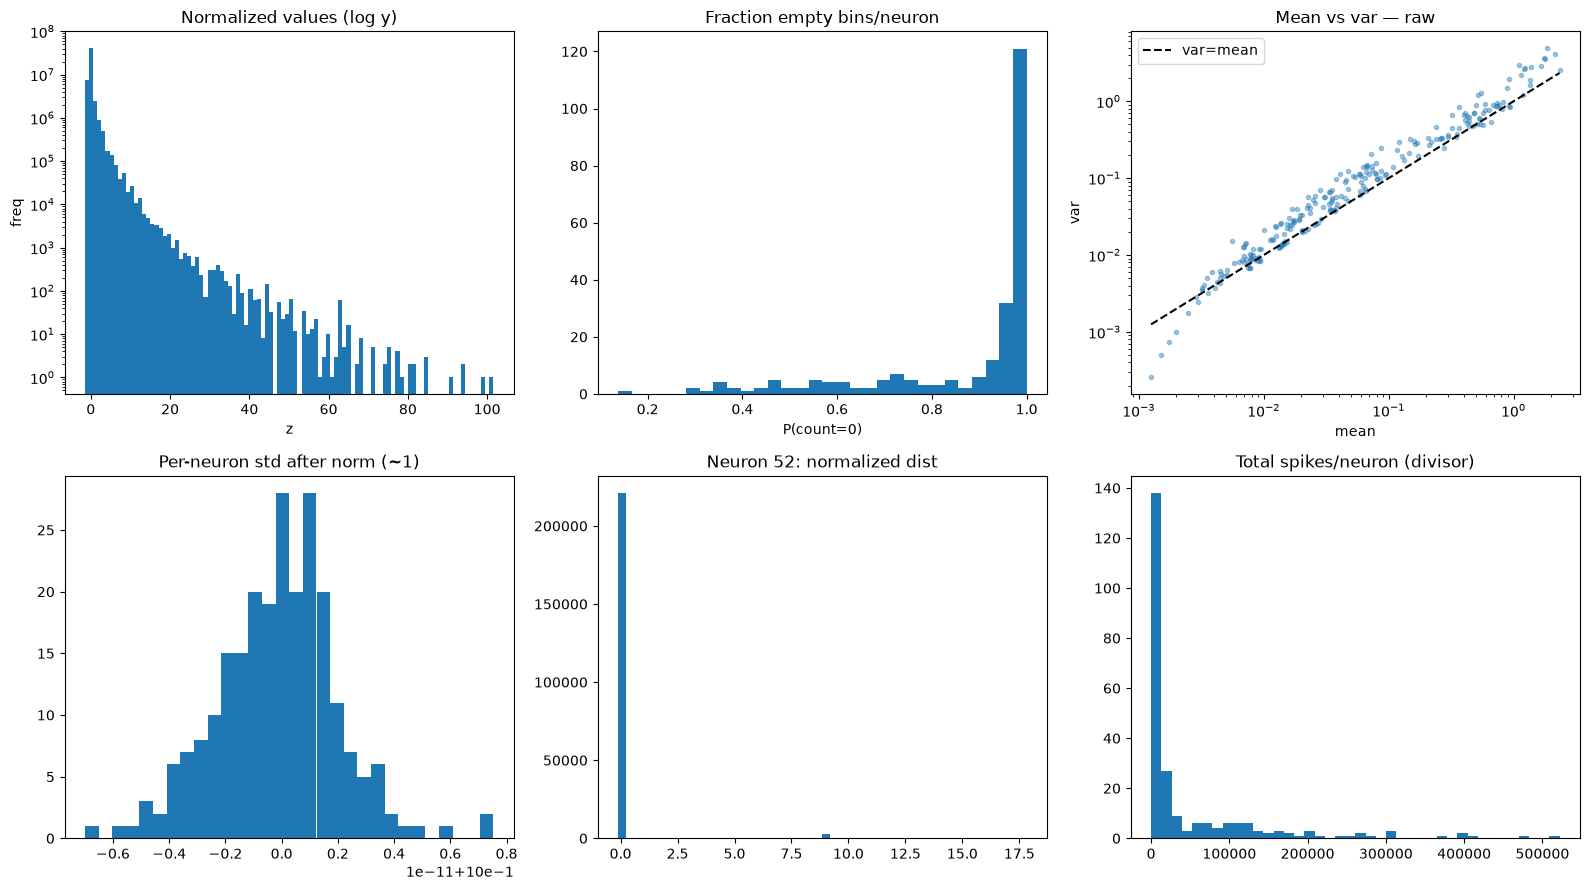

In [15]:
import numpy as np
import matplotlib.pyplot as plt

BIN = 0.050

unit_ids = np.asarray(spike_group.index)
spike_arrays = [spike_group[u].index.values for u in unit_ids]

t_start = min(s[0] for s in spike_arrays if len(s))
t_end   = max(s[-1] for s in spike_arrays if len(s))
edges = np.arange(t_start, t_end + BIN, BIN)
bin_times_s = edges[:-1]
T, N = len(edges) - 1, len(unit_ids)

# histogram does the binning (fast bin-search); one call per neuron
counts = np.stack([np.histogram(spk, bins=edges)[0] for spk in spike_arrays], axis=1).astype(float)
neuron_totals = np.array([spk.size for spk in spike_arrays], dtype=float)

# vectorized divide-by-total then z-score
neuron_totals[neuron_totals == 0] = 1
prop = counts / neuron_totals
spike_matrix_norm = (prop - prop.mean(0)) / np.where(prop.std(0) == 0, 1, prop.std(0))

print(f"matrix: {spike_matrix_norm.shape} | NaN/inf:",
      np.isnan(spike_matrix_norm).any(), np.isinf(spike_matrix_norm).any())

fig, ax = plt.subplots(2, 3, figsize=(16, 9))
ax[0,0].hist(spike_matrix_norm.ravel(), bins=100, log=True)
ax[0,0].set(title="Normalized values (log y)", xlabel="z", ylabel="freq")
frac_zero = (counts == 0).mean(0)
ax[0,1].hist(frac_zero, bins=30); ax[0,1].set(title="Fraction empty bins/neuron", xlabel="P(count=0)")
m, v = counts.mean(0), counts.var(0)
ax[0,2].loglog(m+1e-3, v+1e-6, ".", alpha=0.4)
lims=[m.min()+1e-3, m.max()]; ax[0,2].plot(lims, lims, "k--", label="var=mean")
ax[0,2].set(title="Mean vs var — raw", xlabel="mean", ylabel="var"); ax[0,2].legend()
ax[1,0].hist(spike_matrix_norm.std(0), bins=30); ax[1,0].set(title="Per-neuron std after norm (~1)")
lo = np.argsort(neuron_totals)[N//4]
ax[1,1].hist(spike_matrix_norm[:, lo], bins=50); ax[1,1].set(title=f"Neuron {lo}: normalized dist")
ax[1,2].hist(neuron_totals, bins=40); ax[1,2].set(title="Total spikes/neuron (divisor)")
plt.tight_layout(); plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

BIN = 0.050
binned = spike_group.count(BIN)          # TsdFrame [T x N], raw counts
counts = binned.values.astype(float)     # T bins x N neurons
firing_rates = counts.mean(0) / BIN      # per-neuron mean rate (Hz)

fig, ax = plt.subplots(2, 3, figsize=(16, 9))

# 1) distribution of raw counts across ALL neurons/bins — is it spiky at 0?
ax[0,0].hist(counts.ravel(), bins=np.arange(0, counts.max()+2)-0.5, log=True)
ax[0,0].set(title="Raw spike counts per bin (log y)", xlabel="count", ylabel="freq")

# 2) sparsity: fraction of bins that are ZERO, per neuron
frac_zero = (counts == 0).mean(0)
ax[0,1].hist(frac_zero, bins=30)
ax[0,1].set(title="Fraction of empty bins per neuron", xlabel="P(count=0)", ylabel="# neurons")

# 3) mean vs variance per neuron — Poisson sits on y=x; Gaussian wants flat
unit_mean = counts.mean(0); unit_var = counts.var(0)
ax[0,2].loglog(unit_mean, unit_var, ".", alpha=0.4)
lims = [unit_mean.min()+1e-3, unit_mean.max()]
ax[0,2].plot(lims, lims, "k--", label="var=mean (Poisson)")
ax[0,2].set(title="Mean vs variance per neuron", xlabel="mean", ylabel="variance"); ax[0,2].legend()

# 4) per-neuron firing-rate spread — how heterogeneous are the scales?
ax[1,0].hist(firing_rates, bins=40)
ax[1,0].set(title="Per-neuron firing rate", xlabel="Hz", ylabel="# neurons")

# 5) example single-neuron count distribution (a low-rate one) raw vs sqrt
lo = np.argsort(firing_rates)[len(firing_rates)//4]   # a lowish-rate neuron
ax[1,1].hist(counts[:, lo], bins=30, alpha=0.6, label="raw")
ax[1,1].hist(np.sqrt(counts[:, lo]), bins=30, alpha=0.6, label="sqrt")
ax[1,1].set(title=f"Neuron {lo}: raw vs sqrt", xlabel="value"); ax[1,1].legend()

# 6) does z-scoring equalize scales? std per neuron after z-score should be ~1
zc = (counts - counts.mean(0)) / np.where(counts.std(0)==0, 1, counts.std(0))
ax[1,2].hist(zc.std(0), bins=30)
ax[1,2].set(title="Per-neuron std after z-score", xlabel="std (should be ~1)", ylabel="# neurons")

plt.tight_layout(); plt.show()

print(f"median firing rate: {np.median(firing_rates):.2f} Hz")
print(f"median P(empty bin): {np.median(frac_zero):.2f}")
print(f"mean/var correlation: overdispersed if var >> mean")